In [1]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import numpy as np
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input

In [2]:
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
EPOCHS = 50

In [3]:

IMAGES_PATH = "/Volumes/T9/HAM10000"
CSV_PATH = "/Volumes/T9/HAM10000_metadata.csv"
df = pd.read_csv("/Volumes/T9/HAM10000_metadata.csv")
# Définition des classes à conserver
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

In [34]:
df

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face


In [4]:

# 📁 Mapping des chemins images dans une nouvelle colonne 'path'
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))

# 🏷️ Label to index mapping
label_to_index = {v: k for k, v in CLASS_LABELS.items()}
df = df[df['dx'].isin(CLASS_LABELS.values())]
df['label'] = df['dx'].map(label_to_index)


In [5]:
import os
import shutil
from sklearn.model_selection import train_test_split
import pandas as pd

# === 0. Paramètres ===
DATASET_DIR = '/Volumes/T9/HAM10000'  # répertoire contenant toutes les images originales
SAVE_DIR = '/Volumes/T9/HAM10000/data_split'  # répertoire cible pour sauvegarde
os.makedirs(SAVE_DIR, exist_ok=True)

# === 1. Split en 70% train, 15% val, 15% test ===
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

# Conversion des labels en str (requis pour Keras et ImageDataGenerator)
for subset in [train_df, val_df, test_df]:
    subset['label'] = subset['label'].astype(str)



In [5]:
# --- Labels ---
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# --- Mappings utiles ---
label_to_index = {v: k for k, v in CLASS_LABELS.items()}
index_to_label = {k: v for k, v in CLASS_LABELS.items()}
ordered_names = [CLASS_LABELS[i] for i in range(len(CLASS_LABELS))]

2025-08-29 07:40:40.814151: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-08-29 07:40:40.814197: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-08-29 07:40:40.814201: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1756446040.814454   10650 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1756446040.814707   10650 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-08-29 07:40:47.300801: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 259ms/step


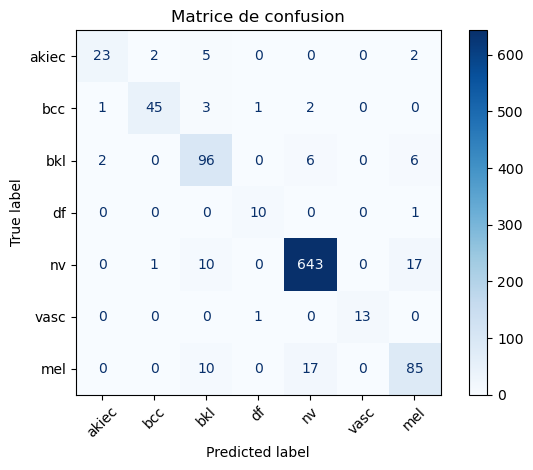

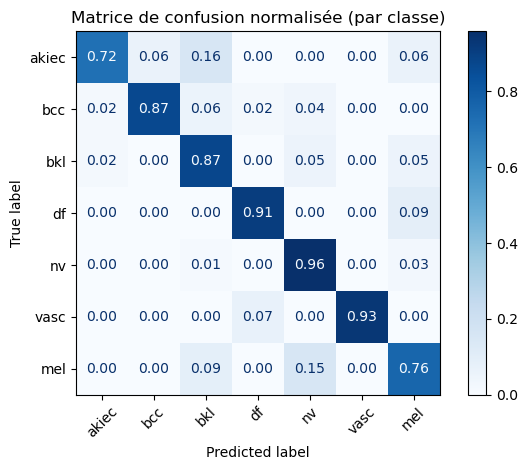

Rapport de classification :
              precision    recall  f1-score   support

       akiec       0.88      0.72      0.79        32
         bcc       0.94      0.87      0.90        52
         bkl       0.77      0.87      0.82       110
          df       0.83      0.91      0.87        11
          nv       0.96      0.96      0.96       671
        vasc       1.00      0.93      0.96        14
         mel       0.77      0.76      0.76       112

    accuracy                           0.91      1002
   macro avg       0.88      0.86      0.87      1002
weighted avg       0.92      0.91      0.91      1002



In [6]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 IMAGE et PREPROCESS
from tensorflow.keras.applications.xception import preprocess_input
IMG_SIZE = (299, 299)

# --- Labels ---
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# --- Mappings utiles ---
label_to_index = {v: k for k, v in CLASS_LABELS.items()}
index_to_label = {k: v for k, v in CLASS_LABELS.items()}
ordered_names = [CLASS_LABELS[i] for i in range(len(CLASS_LABELS))]

# 1) NE PAS forcer en str — au contraire, on normalise proprement plus bas
# test_df['label'] = test_df['label'].astype(str)  # ⛔️ on enlève

# 2) Charger le modèle
model = load_model('/Volumes/T9/Protocole-S-Best/Protocole-S-Xception.keras', compile=False)

# 3) Prétraitement image
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 4) Normalisation robuste des labels → indices [0..6]
def to_index_array(labels):
    indices = []
    for l in labels:
        if pd.isna(l):
            raise ValueError("Label manquant (NaN) détecté.")
        # déjà int
        if isinstance(l, (int, np.integer)):
            indices.append(int(l))
            continue
        s = str(l)
        # chaîne d’index ('0'..'6')
        if s.isdigit():
            indices.append(int(s))
            continue
        # nom de classe ('mel', 'akiec', ...)
        if s in label_to_index:
            indices.append(label_to_index[s])
            continue
        raise KeyError(f"Label inconnu: {s} (attendus: {ordered_names} ou indices 0..6)")
    return np.array(indices, dtype=int)

# 5) Préparer les données
X_test = preprocess_images(test_df['path'])
y_true_raw = test_df['label'].values
y_true_encoded = to_index_array(y_true_raw)

# 6) Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 7) Matrice de confusion (brute)
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordered_names)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# (Optionnel) Matrice normalisée par ligne (%)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=ordered_names)
disp_norm.plot(xticks_rotation=45, cmap="Blues", values_format=".2f")
plt.title("Matrice de confusion normalisée (par classe)")
plt.tight_layout()
plt.show()

# 8) Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=ordered_names))


32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 265ms/step


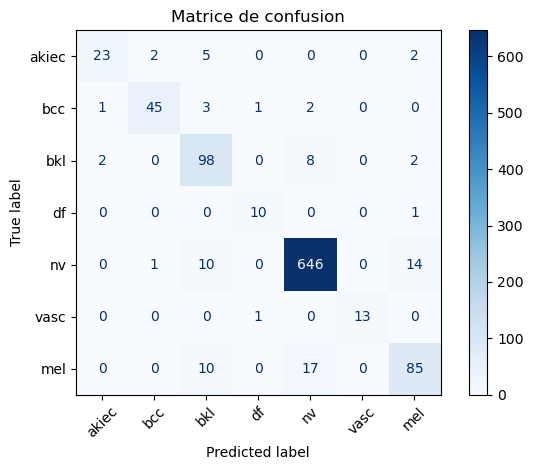

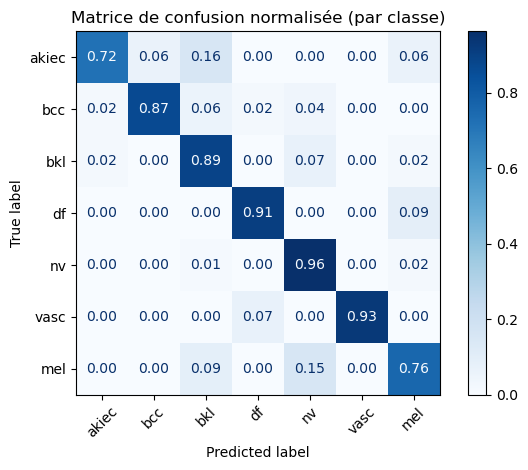

Rapport de classification :
              precision    recall  f1-score   support

       akiec       0.88      0.72      0.79        32
         bcc       0.94      0.87      0.90        52
         bkl       0.78      0.89      0.83       110
          df       0.83      0.91      0.87        11
          nv       0.96      0.96      0.96       671
        vasc       1.00      0.93      0.96        14
         mel       0.82      0.76      0.79       112

    accuracy                           0.92      1002
   macro avg       0.89      0.86      0.87      1002
weighted avg       0.92      0.92      0.92      1002



In [18]:
## Al a recherche 


import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 IMAGE et PREPROCESS
from tensorflow.keras.applications.xception import preprocess_input
IMG_SIZE = (299, 299)

# --- Labels ---
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# --- Mappings utiles ---
label_to_index = {v: k for k, v in CLASS_LABELS.items()}
index_to_label = {k: v for k, v in CLASS_LABELS.items()}
ordered_names = [CLASS_LABELS[i] for i in range(len(CLASS_LABELS))]

# 1) NE PAS forcer en str — au contraire, on normalise proprement plus bas
# test_df['label'] = test_df['label'].astype(str)  # ⛔️ on enlève

# 2) Charger le modèle
model = load_model('Protocole-S-V2-Xception-phaseAvecTAG4-valAUC.keras', compile=False)

# 3) Prétraitement image
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 4) Normalisation robuste des labels → indices [0..6]
def to_index_array(labels):
    indices = []
    for l in labels:
        if pd.isna(l):
            raise ValueError("Label manquant (NaN) détecté.")
        # déjà int
        if isinstance(l, (int, np.integer)):
            indices.append(int(l))
            continue
        s = str(l)
        # chaîne d’index ('0'..'6')
        if s.isdigit():
            indices.append(int(s))
            continue
        # nom de classe ('mel', 'akiec', ...)
        if s in label_to_index:
            indices.append(label_to_index[s])
            continue
        raise KeyError(f"Label inconnu: {s} (attendus: {ordered_names} ou indices 0..6)")
    return np.array(indices, dtype=int)

# 5) Préparer les données
X_test = preprocess_images(test_df['path'])
y_true_raw = test_df['label'].values
y_true_encoded = to_index_array(y_true_raw)

# 6) Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 7) Matrice de confusion (brute)
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordered_names)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# (Optionnel) Matrice normalisée par ligne (%)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=ordered_names)
disp_norm.plot(xticks_rotation=45, cmap="Blues", values_format=".2f")
plt.title("Matrice de confusion normalisée (par classe)")
plt.tight_layout()
plt.show()

# 8) Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=ordered_names))




32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 184ms/step


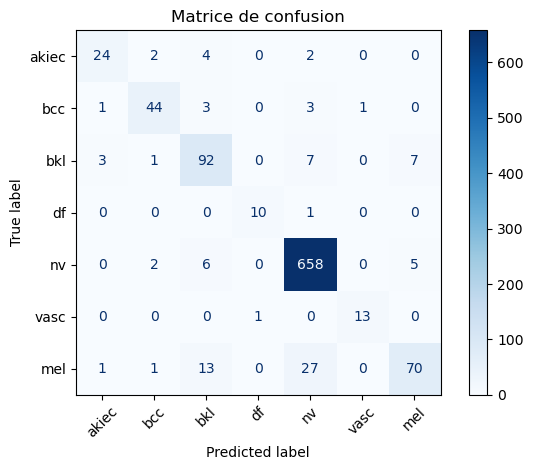

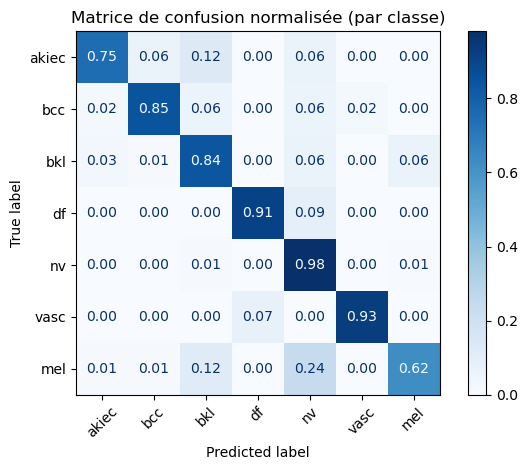

Rapport de classification :
              precision    recall  f1-score   support

       akiec       0.83      0.75      0.79        32
         bcc       0.88      0.85      0.86        52
         bkl       0.78      0.84      0.81       110
          df       0.91      0.91      0.91        11
          nv       0.94      0.98      0.96       671
        vasc       0.93      0.93      0.93        14
         mel       0.85      0.62      0.72       112

    accuracy                           0.91      1002
   macro avg       0.87      0.84      0.85      1002
weighted avg       0.91      0.91      0.91      1002



In [7]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 IMAGE et PREPROCESS
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
IMG_SIZE = (299, 299)

# --- Labels ---
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# --- Mappings utiles ---
label_to_index = {v: k for k, v in CLASS_LABELS.items()}
index_to_label = {k: v for k, v in CLASS_LABELS.items()}
ordered_names = [CLASS_LABELS[i] for i in range(len(CLASS_LABELS))]

# 1) NE PAS forcer en str — au contraire, on normalise proprement plus bas
# test_df['label'] = test_df['label'].astype(str)  # ⛔️ on enlève

# 2) Charger le modèle
model = load_model('/Volumes/T9/Protocole-S-Best/Protocole-S-InceptionV3.keras', compile=False)

# 3) Prétraitement image
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 4) Normalisation robuste des labels → indices [0..6]
def to_index_array(labels):
    indices = []
    for l in labels:
        if pd.isna(l):
            raise ValueError("Label manquant (NaN) détecté.")
        # déjà int
        if isinstance(l, (int, np.integer)):
            indices.append(int(l))
            continue
        s = str(l)
        # chaîne d’index ('0'..'6')
        if s.isdigit():
            indices.append(int(s))
            continue
        # nom de classe ('mel', 'akiec', ...)
        if s in label_to_index:
            indices.append(label_to_index[s])
            continue
        raise KeyError(f"Label inconnu: {s} (attendus: {ordered_names} ou indices 0..6)")
    return np.array(indices, dtype=int)

# 5) Préparer les données
X_test = preprocess_images(test_df['path'])
y_true_raw = test_df['label'].values
y_true_encoded = to_index_array(y_true_raw)

# 6) Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 7) Matrice de confusion (brute)
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordered_names)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# (Optionnel) Matrice normalisée par ligne (%)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=ordered_names)
disp_norm.plot(xticks_rotation=45, cmap="Blues", values_format=".2f")
plt.title("Matrice de confusion normalisée (par classe)")
plt.tight_layout()
plt.show()

# 8) Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=ordered_names))


32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 169ms/step


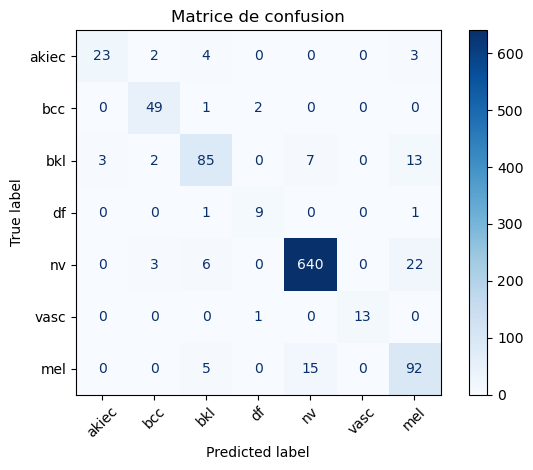

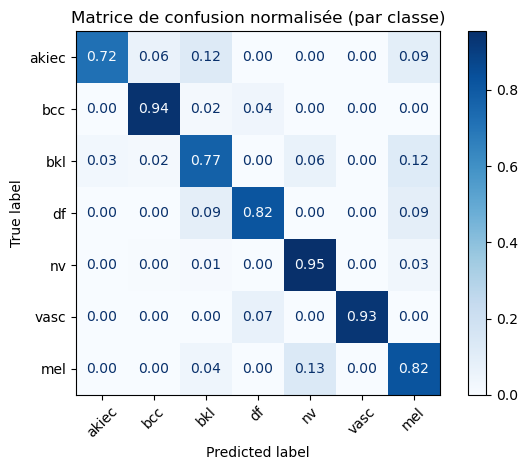

Rapport de classification :
              precision    recall  f1-score   support

       akiec       0.88      0.72      0.79        32
         bcc       0.88      0.94      0.91        52
         bkl       0.83      0.77      0.80       110
          df       0.75      0.82      0.78        11
          nv       0.97      0.95      0.96       671
        vasc       1.00      0.93      0.96        14
         mel       0.70      0.82      0.76       112

    accuracy                           0.91      1002
   macro avg       0.86      0.85      0.85      1002
weighted avg       0.91      0.91      0.91      1002



In [ ]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 IMAGE et PREPROCESS
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
IMG_SIZE = (224, 224)

# --- Labels ---
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# --- Mappings utiles ---
label_to_index = {v: k for k, v in CLASS_LABELS.items()}
index_to_label = {k: v for k, v in CLASS_LABELS.items()}
ordered_names = [CLASS_LABELS[i] for i in range(len(CLASS_LABELS))]

# 1) NE PAS forcer en str — au contraire, on normalise proprement plus bas
# test_df['label'] = test_df['label'].astype(str)  # ⛔️ on enlève

# 2) Charger le modèle
model = load_model('/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras', compile=False)

# 3) Prétraitement image
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_resnet(img_array)
    return img_array

def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 4) Normalisation robuste des labels → indices [0..6]
def to_index_array(labels):
    indices = []
    for l in labels:
        if pd.isna(l):
            raise ValueError("Label manquant (NaN) détecté.")
        # déjà int
        if isinstance(l, (int, np.integer)):
            indices.append(int(l))
            continue
        s = str(l)
        # chaîne d’index ('0'..'6')
        if s.isdigit():
            indices.append(int(s))
            continue
        # nom de classe ('mel', 'akiec', ...)
        if s in label_to_index:
            indices.append(label_to_index[s])
            continue
        raise KeyError(f"Label inconnu: {s} (attendus: {ordered_names} ou indices 0..6)")
    return np.array(indices, dtype=int)

# 5) Préparer les données
X_test = preprocess_images(test_df['path'])
y_true_raw = test_df['label'].values
y_true_encoded = to_index_array(y_true_raw)

# 6) Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 7) Matrice de confusion (brute)
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordered_names)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# (Optionnel) Matrice normalisée par ligne (%)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=ordered_names)
disp_norm.plot(xticks_rotation=45, cmap="Blues", values_format=".2f")
plt.title("Matrice de confusion normalisée (par classe)")
plt.tight_layout()
plt.show()

# 8) Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=ordered_names))


32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 429ms/step


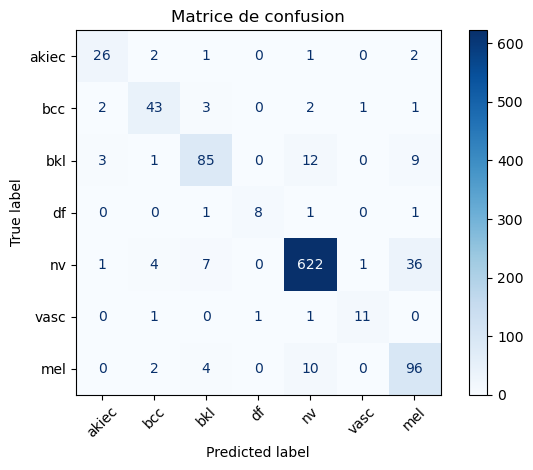

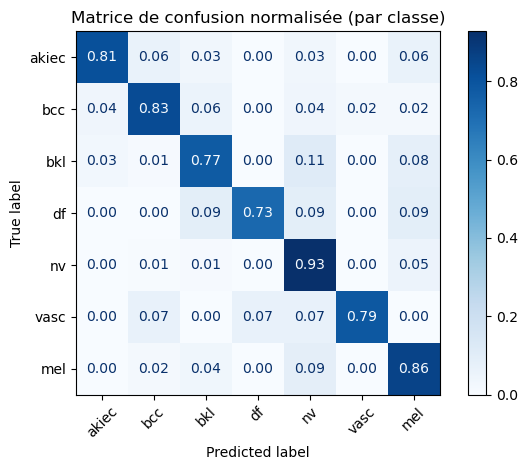

Rapport de classification :
              precision    recall  f1-score   support

       akiec       0.81      0.81      0.81        32
         bcc       0.81      0.83      0.82        52
         bkl       0.84      0.77      0.81       110
          df       0.89      0.73      0.80        11
          nv       0.96      0.93      0.94       671
        vasc       0.85      0.79      0.81        14
         mel       0.66      0.86      0.75       112

    accuracy                           0.89      1002
   macro avg       0.83      0.82      0.82      1002
weighted avg       0.90      0.89      0.89      1002



In [ ]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 IMAGE et PREPROCESS
from tensorflow.keras.applications.densenet import preprocess_input
IMG_SIZE = (224, 224)

# --- Labels ---
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# --- Mappings utiles ---
label_to_index = {v: k for k, v in CLASS_LABELS.items()}
index_to_label = {k: v for k, v in CLASS_LABELS.items()}
ordered_names = [CLASS_LABELS[i] for i in range(len(CLASS_LABELS))]

# 1) NE PAS forcer en str — au contraire, on normalise proprement plus bas
# test_df['label'] = test_df['label'].astype(str)  # ⛔️ on enlève

# 2) Charger le modèle
model = load_model('Protocole-S-V2-Densenet201-Phase8-11-valAUC.keras', compile=False)

# 3) Prétraitement image
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 4) Normalisation robuste des labels → indices [0..6]
def to_index_array(labels):
    indices = []
    for l in labels:
        if pd.isna(l):
            raise ValueError("Label manquant (NaN) détecté.")
        # déjà int
        if isinstance(l, (int, np.integer)):
            indices.append(int(l))
            continue
        s = str(l)
        # chaîne d’index ('0'..'6')
        if s.isdigit():
            indices.append(int(s))
            continue
        # nom de classe ('mel', 'akiec', ...)
        if s in label_to_index:
            indices.append(label_to_index[s])
            continue
        raise KeyError(f"Label inconnu: {s} (attendus: {ordered_names} ou indices 0..6)")
    return np.array(indices, dtype=int)

# 5) Préparer les données
X_test = preprocess_images(test_df['path'])
y_true_raw = test_df['label'].values
y_true_encoded = to_index_array(y_true_raw)

# 6) Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 7) Matrice de confusion (brute)
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordered_names)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# (Optionnel) Matrice normalisée par ligne (%)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=ordered_names)
disp_norm.plot(xticks_rotation=45, cmap="Blues", values_format=".2f")
plt.title("Matrice de confusion normalisée (par classe)")
plt.tight_layout()
plt.show()

# 8) Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=ordered_names))



Évaluation de l'ensemble pondéré (Xception + ResNet50 + DenseNet201)...


Prédiction par batchs: 100%|██████████| 32/32 [01:13<00:00,  2.29s/it]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.96      0.78      0.86        32
         bcc       0.98      0.92      0.95        52
         bkl       0.83      0.87      0.85       110
          df       0.91      0.91      0.91        11
          nv       0.97      0.96      0.97       671
        vasc       1.00      0.93      0.96        14
         mel       0.77      0.84      0.80       112

    accuracy                           0.93      1002
   macro avg       0.92      0.89      0.90      1002
weighted avg       0.93      0.93      0.93      1002



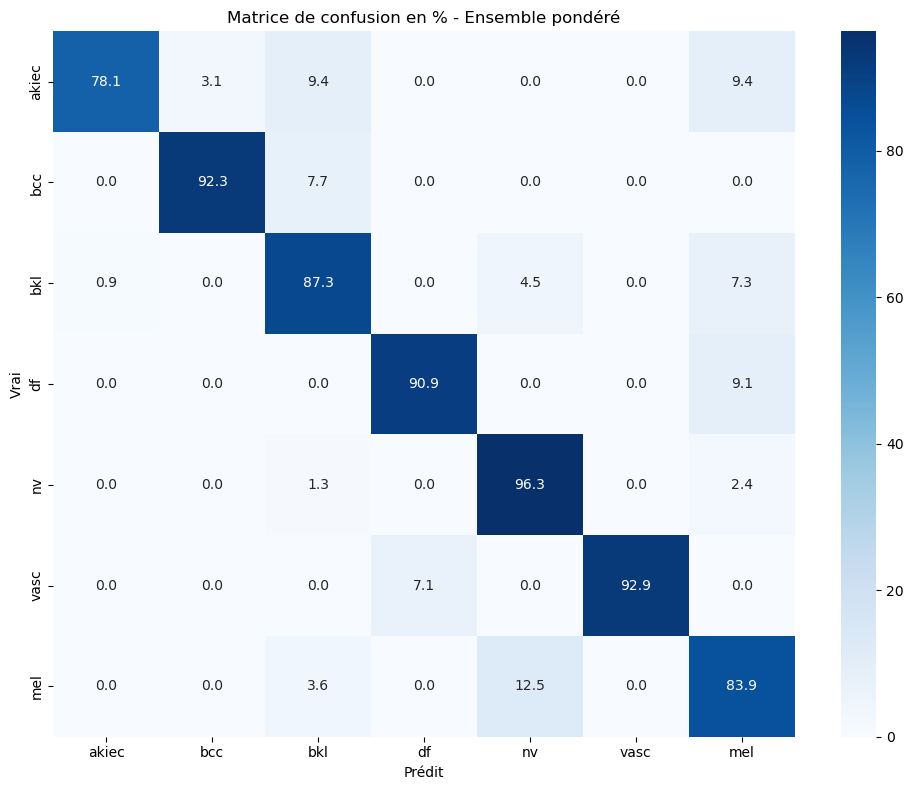

In [14]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet

# ---- Configuration ----
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}

# ---- DataFrame df supposé dispo ----
df = df[df['dx'].isin(CLASS_NAMES)]
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
df['label'] = df['dx'].map(label_to_index)

# Split train/val/test
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# ---- Chargement des modèles ----
model_xcept    = load_model("Protocole-S-V2-Xception-phaseSansTAG-valACC.keras", compile=False)
model_resnet50 = load_model("/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras", compile=False)
model_densenet = load_model("Protocole-S-V2-Densenet201-Phase8-11-valAUC.keras", compile=False)

# ---- Préparation images ----
def load_image_paths(paths, target_size):
    return np.array([
        image.img_to_array(
            image.load_img(p, target_size=target_size, color_mode="rgb")
        ) for p in paths
    ])

# ---- Prédiction en batch avec priorisation DenseNet201 sur mel ----

#weights=(0.45, 0.25, 0.30)
def predict_ensemble(image_paths, batch_size=32, weights=(0.50, 0.25, 0.25)):
    """
    weights = (w_xception, w_resnet50, w_densenet201)
    """
    num_images = len(image_paths)
    all_predictions = []

    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction par batchs"):
        batch_paths = image_paths[i:i + batch_size]

        # Chargement images adaptées
        bx = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        br = preprocess_resnet(load_image_paths(batch_paths, (224, 224)))
        bd = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))

        # Prédictions
        pred_x = model_xcept.predict(bx, verbose=0)
        pred_r = model_resnet50.predict(br, verbose=0)
        pred_d = model_densenet.predict(bd, verbose=0)

        # Moyenne pondérée
        preds = (weights[0] * pred_x +
                 weights[1] * pred_r +
                 weights[2] * pred_d)

        # --- ASTUCE : privilégier DenseNet201 pour 'mel' (classe index 6) ---
        mel_idx = label_to_index['mel']
        preds[:, mel_idx] = (0.5 * preds[:, mel_idx] + 0.5 * pred_d[:, mel_idx])

        all_predictions.extend(np.argmax(preds, axis=1))

    return np.array(all_predictions)

# ---- Évaluation ----
print("\nÉvaluation de l'ensemble pondéré (Xception + ResNet50 + DenseNet201)...")

y_true = test_df['label'].values
y_pred = predict_ensemble(test_df['path'].tolist())

print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                            target_names=CLASS_NAMES,
                            labels=np.arange(len(CLASS_NAMES))))

# ---- Matrice de confusion en % ----
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré')
plt.tight_layout()
plt.show()


## TEST avec Average Specificity et Average AUC


Évaluation de l'ensemble pondéré (Xception + ResNet50 + DenseNet201)...


Prédiction par batchs: 100%|██████████| 32/32 [01:41<00:00,  3.17s/it]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.96      0.78      0.86        32
         bcc       0.98      0.92      0.95        52
         bkl       0.83      0.87      0.85       110
          df       0.91      0.91      0.91        11
          nv       0.97      0.96      0.97       671
        vasc       1.00      0.93      0.96        14
         mel       0.77      0.84      0.80       112

    accuracy                           0.93      1002
   macro avg       0.92      0.89      0.90      1002
weighted avg       0.93      0.93      0.93      1002



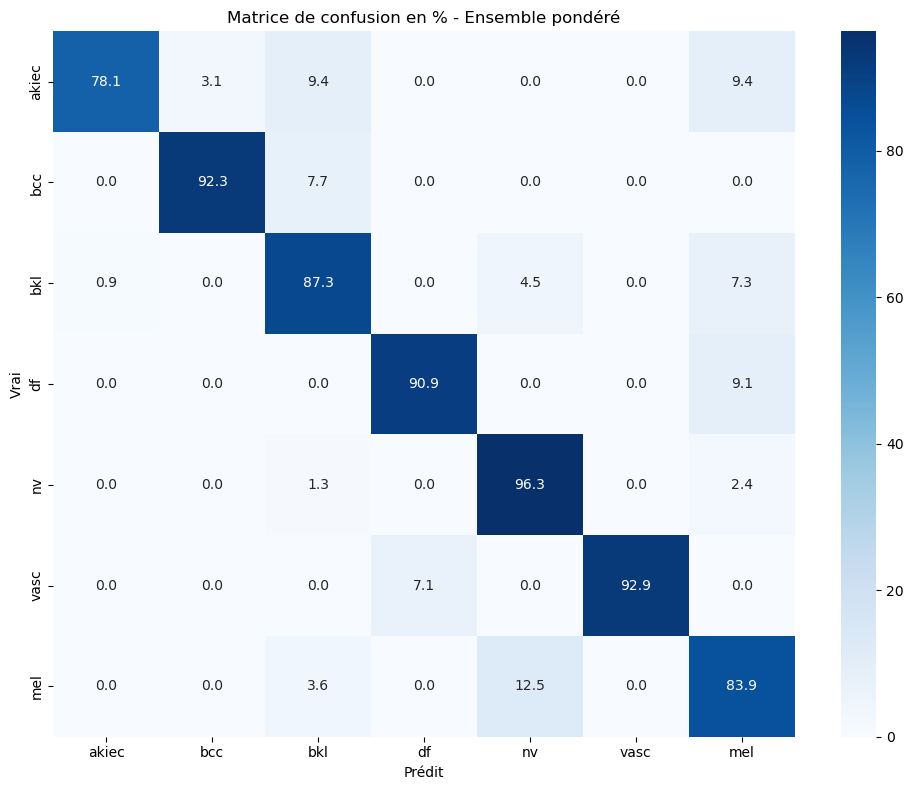


Average AUC: 0.9901
AUC par classe:
akiec: 0.9909
bcc: 0.9975
bkl: 0.9811
df: 0.9999
nv: 0.9879
vasc: 1.0000
mel: 0.9735

Average Specificity: 0.9827
Specificity par classe:
akiec: 0.9989
bcc: 0.9989
bkl: 0.9766
df: 0.9989
nv: 0.9377
vasc: 1.0000
mel: 0.9677


In [17]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_fscore_support
)
from tqdm import tqdm
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet

# ---- Configuration ----
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}

# ---- DataFrame df supposé dispo ----
df = df[df['dx'].isin(CLASS_NAMES)]
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
df['label'] = df['dx'].map(label_to_index)

# Split train/val/test
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# ---- Chargement des modèles ----
model_xcept    = load_model("Protocole-S-V2-Xception-phaseSansTAG-valACC.keras", compile=False)
model_resnet50 = load_model("/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras", compile=False)
model_densenet = load_model("Protocole-S-V2-Densenet201-Phase8-11-valAUC.keras", compile=False)

# ---- Préparation images ----
def load_image_paths(paths, target_size):
    return np.array([
        image.img_to_array(
            image.load_img(p, target_size=target_size, color_mode="rgb")
        ) for p in paths
    ])

# ---- Prédiction en batch avec priorisation DenseNet201 sur mel ----
def predict_ensemble_proba(image_paths, batch_size=32, weights=(0.50, 0.25, 0.25)):
    """
    Retourne les probabilités de prédiction pour chaque classe.
    weights = (w_xception, w_resnet50, w_densenet201)
    """
    num_images = len(image_paths)
    all_probs = []
    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction par batchs"):
        batch_paths = image_paths[i:i + batch_size]
        # Chargement images adaptées
        bx = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        br = preprocess_resnet(load_image_paths(batch_paths, (224, 224)))
        bd = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))
        # Prédictions
        pred_x = model_xcept.predict(bx, verbose=0)
        pred_r = model_resnet50.predict(br, verbose=0)
        pred_d = model_densenet.predict(bd, verbose=0)
        # Moyenne pondérée
        preds = (weights[0] * pred_x +
                 weights[1] * pred_r +
                 weights[2] * pred_d)
        # ASTUCE : privilégier DenseNet201 pour 'mel' (classe index 6)
        mel_idx = label_to_index['mel']
        preds[:, mel_idx] = (0.5 * preds[:, mel_idx] + 0.5 * pred_d[:, mel_idx])
        all_probs.extend(preds)
    return np.array(all_probs)

# ---- Évaluation ----
print("\nÉvaluation de l'ensemble pondéré (Xception + ResNet50 + DenseNet201)...")
y_true = test_df['label'].values
y_probs = predict_ensemble_proba(test_df['path'].tolist())
y_pred = np.argmax(y_probs, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                            target_names=CLASS_NAMES,
                            labels=np.arange(len(CLASS_NAMES))))

# Matrice de confusion en %
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré')
plt.tight_layout()
plt.show()

# ---- Calcul de l'AUC moyenne ----
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=len(CLASS_NAMES))
auc_scores = roc_auc_score(y_true_onehot, y_probs, average=None)
average_auc = np.mean(auc_scores)
print(f"\nAverage AUC: {average_auc:.4f}")
print("AUC par classe:")
for i, class_name in enumerate(CLASS_NAMES):
    print(f"{class_name}: {auc_scores[i]:.4f}")

# ---- Calcul de la Specificity moyenne ----
specificity_scores = []
for i in range(len(CLASS_NAMES)):
    # True Negatives = somme des vrais négatifs pour la classe i
    TN = np.sum(conf_matrix[np.arange(conf_matrix.shape[0]) != i, np.arange(conf_matrix.shape[1]) != i])
    # False Positives = somme des faux positifs pour la classe i
    FP = np.sum(conf_matrix[np.arange(conf_matrix.shape[0]) != i, i])
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    specificity_scores.append(specificity)
average_specificity = np.mean(specificity_scores)
print(f"\nAverage Specificity: {average_specificity:.4f}")
print("Specificity par classe:")
for i, class_name in enumerate(CLASS_NAMES):
    print(f"{class_name}: {specificity_scores[i]:.4f}")



=== Génération des features OOF pour le stacking ===


Prédictions batchs: 100%|██████████| 51/51 [00:48<00:00,  1.05it/s]



=== Entraînement LightGBM (sklearn API) sur OOF ===

=== Features meta pour le TEST ===


Prédictions batchs: 100%|██████████| 32/32 [00:43<00:00,  1.36s/it]


=== META (LightGBM) sur TEST ===
              precision    recall  f1-score   support

       akiec       0.83      0.78      0.81        32
         bcc       0.85      0.96      0.90        52
         bkl       0.91      0.84      0.87       110
          df       0.92      1.00      0.96        11
          nv       0.95      0.98      0.97       671
        vasc       0.93      0.93      0.93        14
         mel       0.84      0.73      0.78       112

    accuracy                           0.93      1002
   macro avg       0.89      0.89      0.89      1002
weighted avg       0.93      0.93      0.93      1002




/Users/eric/miniforge3/envs/SKINCARE/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


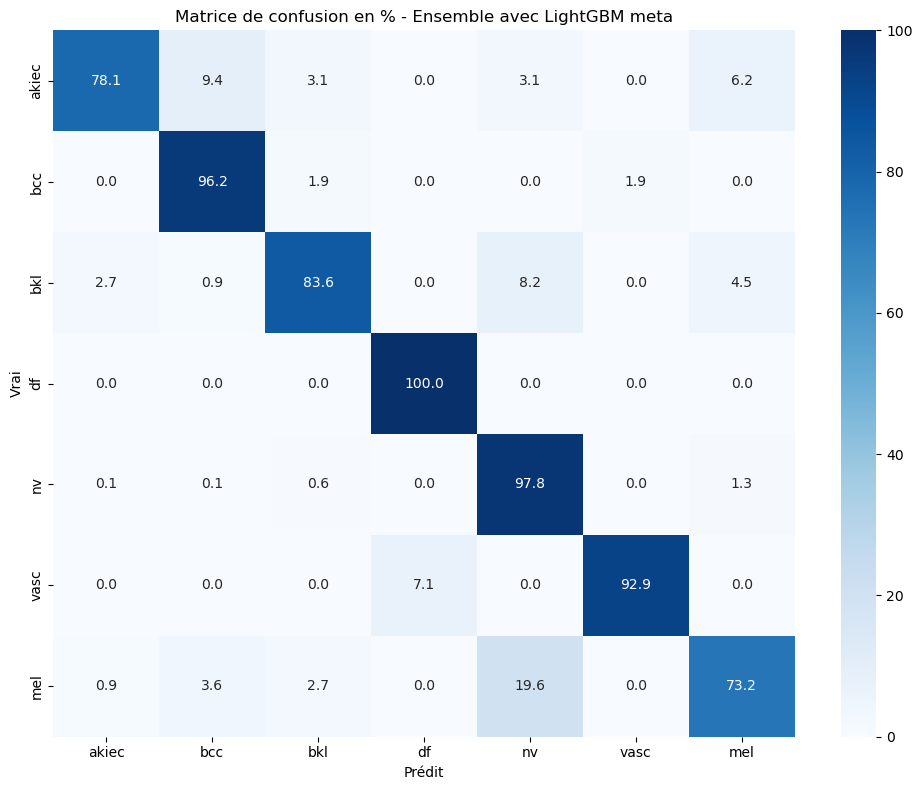

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, train_test_split
from tqdm import tqdm
from lightgbm import LGBMClassifier

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet

# ---- Configuration ----
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}
num_classes = len(CLASS_NAMES)

# ---- DataFrame df supposé dispo ----
df = df[df['dx'].isin(CLASS_NAMES)]
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
df['label'] = df['dx'].map(label_to_index)

# Split train/val/test
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# ---- Chargement des modèles ----
model_xcept    = load_model("Protocole-S-V2-Xception-phaseSansTAG-valACC.keras", compile=False)
model_resnet50 = load_model("/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras", compile=False)
model_densenet = load_model("Protocole-S-V2-Densenet201-Phase8-11-valAUC.keras", compile=False)

# ---- Préparation images ----
def load_image_paths(paths, target_size):
    return np.array([
        image.img_to_array(
            image.load_img(p, target_size=target_size, color_mode="rgb")
        ) for p in paths
    ])

# ---- Fonction pour récupérer les prédictions (probas complètes) ----
def get_model_preds(image_paths, batch_size=32):
    num_images = len(image_paths)
    preds_x, preds_r, preds_d = [], [], []

    for i in tqdm(range(0, num_images, batch_size), desc="Prédictions batchs"):
        batch_paths = image_paths[i:i + batch_size]

        bx = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        br = preprocess_resnet(load_image_paths(batch_paths, (224, 224)))
        bd = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))

        pred_x = model_xcept.predict(bx, verbose=0)
        pred_r = model_resnet50.predict(br, verbose=0)
        pred_d = model_densenet.predict(bd, verbose=0)

        preds_x.append(pred_x)
        preds_r.append(pred_r)
        preds_d.append(pred_d)

    return np.vstack(preds_x), np.vstack(preds_r), np.vstack(preds_d)

# ---- OOF stacking (LightGBM en métamodèle) ----
print("\n=== Génération des features OOF pour le stacking ===")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_oof, y_oof = [], []
for idx_tr, idx_val in skf.split(train_df['path'], train_df['label']):
    tr_paths = train_df.iloc[idx_tr]['path'].tolist()
    val_paths = train_df.iloc[idx_val]['path'].tolist()
    y_tr, y_val = train_df.iloc[idx_tr]['label'].values, train_df.iloc[idx_val]['label'].values

    # prédictions probas
    pred_x_val, pred_r_val, pred_d_val = get_model_preds(val_paths)
    X_val = np.hstack([pred_x_val, pred_r_val, pred_d_val])

    X_oof.append(X_val)
    y_oof.append(y_val)

X_oof = np.vstack(X_oof)
y_oof = np.concatenate(y_oof)

# ---- LightGBM comme métamodèle ----
print("\n=== Entraînement LightGBM (sklearn API) sur OOF ===")
meta_model = LGBMClassifier(
    objective='multiclass',
    num_class=num_classes,
    learning_rate=0.05,
    num_leaves=63,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=1,
    min_child_samples=20,
    random_state=42,
    n_estimators=1500
)

meta_model.fit(
    X_oof, y_oof,
    eval_set=[(X_oof, y_oof)],  # OOF peut servir de validation pour early stopping
    eval_metric="multi_logloss",
    #early_stopping_rounds=100,
    #verbose=100
)

# ---- Évaluation TEST ----
print("\n=== Features meta pour le TEST ===")
pred_x_test, pred_r_test, pred_d_test = get_model_preds(test_df['path'].tolist())
X_test_meta = np.hstack([pred_x_test, pred_r_test, pred_d_test])
y_test = test_df['label'].values

print("\n=== META (LightGBM) sur TEST ===")
y_pred_meta = meta_model.predict(X_test_meta)
print(classification_report(y_test, y_pred_meta, target_names=CLASS_NAMES, labels=np.arange(num_classes)))

# ---- Matrice de confusion ----
conf_matrix = confusion_matrix(y_test, y_pred_meta, labels=np.arange(num_classes))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble avec LightGBM meta')
plt.tight_layout()
plt.show()


2025-08-22 20:52:56.317206: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-08-22 20:52:56.317245: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-08-22 20:52:56.317254: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1755888776.317265   11306 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1755888776.317286   11306 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
Prédictions batch: 100%|██████████| 32/32 [00:34<00:00,  1.09s/it]



=== Entraînement LightGBM meta-model ===

=== Rapport de classification LightGBM meta ===
              precision    recall  f1-score   support

       akiec       0.86      0.75      0.80        32
         bcc       0.92      0.94      0.93        52
         bkl       0.85      0.86      0.86       110
          df       1.00      0.91      0.95        11
          nv       0.96      0.97      0.97       671
        vasc       0.87      0.93      0.90        14
         mel       0.85      0.79      0.82       112

    accuracy                           0.93      1002
   macro avg       0.90      0.88      0.89      1002
weighted avg       0.93      0.93      0.93      1002



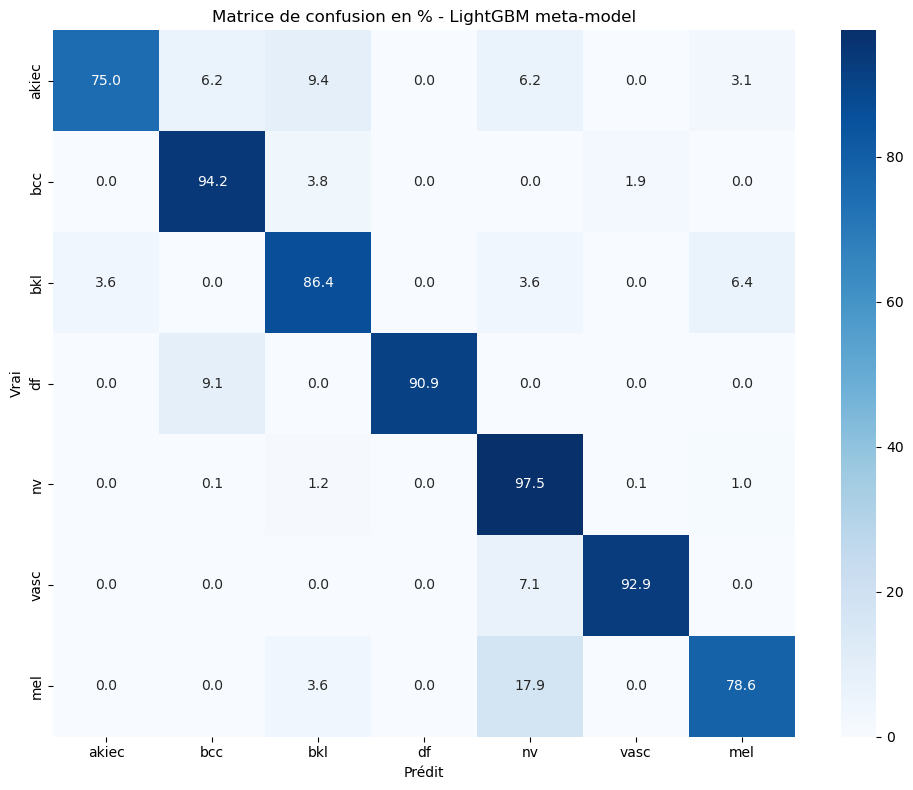

In [ ]:
#Stacking avec comme arbitre LIGHTGBM


import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet

# LightGBM
import lightgbm as lgb

# ---- Configuration ----
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}

# ---- DataFrame df supposé dispo ----
df = df[df['dx'].isin(CLASS_NAMES)]
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
df['label'] = df['dx'].map(label_to_index)

# Split train/val/test
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# ---- Chargement des modèles ----
model_xcept    = load_model("Protocole-S-V2-Xception-phaseSansTAG-valACC.keras", compile=False)
model_resnet50 = load_model("/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras", compile=False)
model_densenet = load_model("Protocole-S-V2-Densenet201-Phase8-11-valAUC.keras", compile=False)

# ---- Préparation images ----
def load_image_paths(paths, target_size):
    return np.array([
        image.img_to_array(
            image.load_img(p, target_size=target_size, color_mode="rgb")
        ) for p in paths
    ])

# ---- Fonction pour extraire les probabilités brutes ----
def get_predictions(models, preprocessors, image_paths, target_sizes, batch_size=32):
    num_images = len(image_paths)
    preds = []
    for i in tqdm(range(0, num_images, batch_size), desc="Prédictions batch"):
        batch_paths = image_paths[i:i+batch_size]

        batch_preds = []
        for model, preproc, tsize in zip(models, preprocessors, target_sizes):
            bx = preproc(load_image_paths(batch_paths, tsize))
            batch_preds.append(model.predict(bx, verbose=0))

        # concaténer les probas de tous les modèles
        preds.append(np.concatenate(batch_preds, axis=1))  # shape: [B, 21]
    return np.vstack(preds)

# ---- Prépare train meta (val set) et test meta (test set) ----
models = [model_xcept, model_resnet50, model_densenet]
preprocs = [preprocess_xception, preprocess_resnet, preprocess_densenet]
tsizes = [(299,299), (224,224), (224,224)]

X_val_meta = get_predictions(models, preprocs, val_df['path'].tolist(), tsizes)
y_val_meta = val_df['label'].values

X_test_meta = get_predictions(models, preprocs, test_df['path'].tolist(), tsizes)
y_test_meta = test_df['label'].values

# ---- LightGBM comme méta-modèle ----
lgb_train = lgb.Dataset(X_val_meta, label=y_val_meta)

params = {
    'objective': 'multiclass',
    'num_class': len(CLASS_NAMES),
    'metric': 'multi_logloss',
    'verbosity': -1,
    'learning_rate': 0.05,
    'num_leaves': 31
}

print("\n=== Entraînement LightGBM meta-model ===")
meta_model = lgb.train(params, lgb_train, num_boost_round=300)

# ---- Prédictions test via le méta-modèle ----
y_pred_proba = meta_model.predict(X_test_meta)  # shape: [N,7]
y_pred = np.argmax(y_pred_proba, axis=1)

print("\n=== Rapport de classification LightGBM meta ===")
print(classification_report(y_test_meta, y_pred,
                            target_names=CLASS_NAMES,
                            labels=np.arange(len(CLASS_NAMES))))

# ---- Matrice de confusion en % ----
conf_matrix = confusion_matrix(y_test_meta, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - LightGBM meta-model')
plt.tight_layout()
plt.show()



Évaluation de l’ensemble pondéré par classe sur l’ensemble de test final...


Prédiction par batchs:   0%|          | 0/32 [00:00<?, ?it/s]

Prédiction par batchs: 100%|██████████| 32/32 [01:16<00:00,  2.40s/it]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.85      0.72      0.78        32
         bcc       0.94      0.96      0.95        52
         bkl       0.90      0.77      0.83       110
          df       0.91      0.91      0.91        11
          nv       0.96      0.97      0.97       671
        vasc       1.00      1.00      1.00        14
         mel       0.77      0.85      0.81       112

    accuracy                           0.93      1002
   macro avg       0.91      0.88      0.89      1002
weighted avg       0.93      0.93      0.93      1002



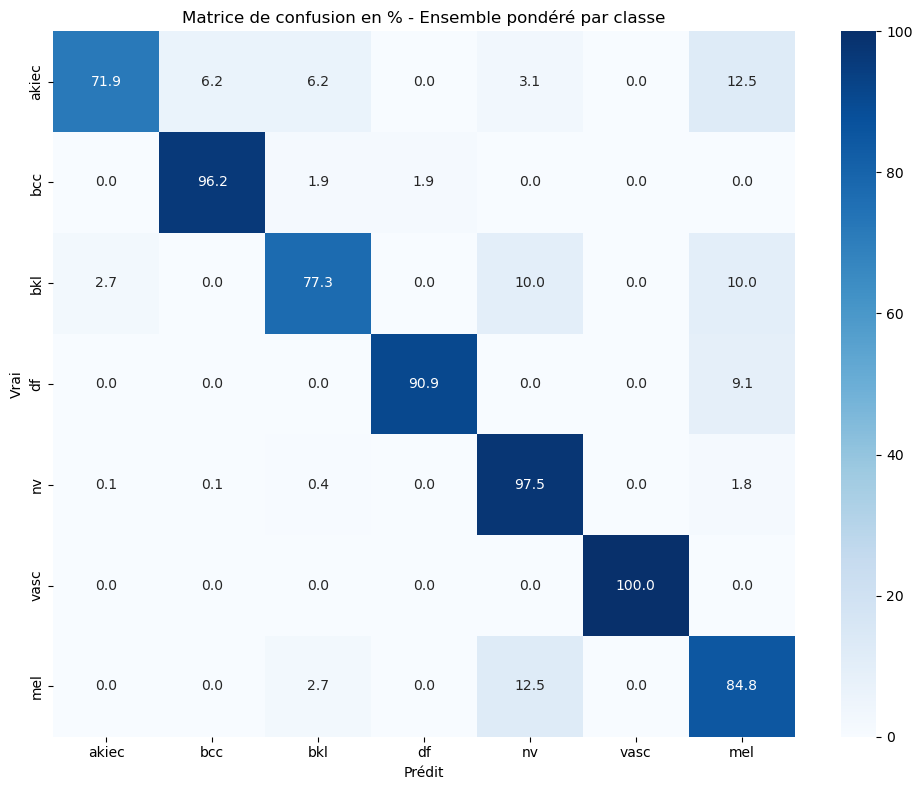

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet

# ---- Configuration ----
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}

# ⚠️ suppose que df et IMAGES_PATH sont déjà définis dans ton env
df = df[df['dx'].isin(CLASS_NAMES)]
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
df['label'] = df['dx'].map(label_to_index)

# Split train/val/test
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# ---- Chargement des modèles ----
model_xcept_big   = load_model("Protocole-S-V2-Xception-phaseSansTAG-valACC.keras", compile=False)
model_resnet50    = load_model("/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras", compile=False)
model_densenet201 = load_model("Protocole-S-V2-Densenet201-Phase8-11-valAUC.keras",
                               compile=False,
                               custom_objects={'preprocess_input': preprocess_densenet})

# ---- Préparation des images ----
def load_image_paths(paths, target_size):
    """Charge et redimensionne les images en RGB array."""
    imgs = np.array([
        image.img_to_array(
            image.load_img(p, target_size=target_size, color_mode="rgb")
        )
        for p in paths
    ])
    return imgs

# ---- Prédiction pondérée par classe ----
def predict_weighted_by_class(image_paths, batch_size=32):
    """
    Ensemble avec pondération par classe :
    - Xception : fort sur BCC, DF, NV, VASC
    - ResNet50 : fort sur BCC, NV, VASC, MEL
    - DenseNet201 : fort sur NV, MEL, AKIEC
    """
    weights_xception = np.array([0.2, 0.9, 0.5, 0.9, 0.9, 0.9, 0.2])
    weights_resnet   = np.array([0.3, 0.9, 0.5, 0.5, 0.9, 0.9, 0.8])
    weights_densenet = np.array([0.8, 0.5, 0.5, 0.5, 0.9, 0.4, 0.9])

    num_images = len(image_paths)
    all_predictions = []

    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction par batchs"):
        batch_paths = image_paths[i:i + batch_size]

        # Chargement et prétraitement
        batch_xcept    = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        batch_resnet   = preprocess_resnet(load_image_paths(batch_paths, (224, 224)))
        batch_densenet = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))

        # Prédictions
        pred_xcept    = model_xcept_big.predict(batch_xcept, verbose=0)
        pred_resnet   = model_resnet50.predict(batch_resnet, verbose=0)
        pred_densenet = model_densenet201.predict(batch_densenet, verbose=0)

        # --- pondération par classe ---
        weighted_preds = (
            pred_xcept * weights_xception +
            pred_resnet * weights_resnet +
            pred_densenet * weights_densenet
        )

        all_predictions.extend(np.argmax(weighted_preds, axis=1))

    return np.array(all_predictions)

# ---- Évaluation ----
print("\nÉvaluation de l’ensemble pondéré par classe sur l’ensemble de test final...")

y_true = test_df['label'].values
y_pred = predict_weighted_by_class(test_df['path'].tolist())

y_true_clean = y_true.astype(int)
y_pred_clean = y_pred.astype(int)

print("\nClassification Report:")
print(classification_report(y_true_clean, y_pred_clean,
                            target_names=CLASS_NAMES,
                            labels=np.arange(len(CLASS_NAMES))))

# ---- Matrice de confusion en pourcentage ----
conf_matrix = confusion_matrix(y_true_clean, y_pred_clean, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré par classe')
plt.tight_layout()
plt.show()



[Calibrage] Calcul des poids par classe à partir du set de validation…

=== F1 sur validation (par classe) ===
 akiec | Xcp: 0.820  RN50: 0.781  DN201: 0.667
   bcc | Xcp: 0.903  RN50: 0.851  DN201: 0.731
   bkl | Xcp: 0.835  RN50: 0.831  DN201: 0.755
    df | Xcp: 0.960  RN50: 0.880  DN201: 0.737
    nv | Xcp: 0.959  RN50: 0.955  DN201: 0.941
  vasc | Xcp: 0.867  RN50: 0.929  DN201: 0.963
   mel | Xcp: 0.778  RN50: 0.780  DN201: 0.733

=== Poids par classe (normalisés, somme=1 par classe) ===
 akiec | Xcp: 0.36  RN50: 0.34  DN201: 0.29
   bcc | Xcp: 0.36  RN50: 0.34  DN201: 0.29
   bkl | Xcp: 0.34  RN50: 0.34  DN201: 0.31
    df | Xcp: 0.37  RN50: 0.34  DN201: 0.29
    nv | Xcp: 0.34  RN50: 0.33  DN201: 0.33
  vasc | Xcp: 0.31  RN50: 0.34  DN201: 0.35
   mel | Xcp: 0.34  RN50: 0.34  DN201: 0.32

[Évaluation] Ensemble dynamique sur le set de test…


Prédiction ensemble (dynamic): 100%|██████████| 32/32 [00:45<00:00,  1.41s/it]


Classification Report (test) :
              precision    recall  f1-score   support

       akiec       0.92      0.72      0.81        32
         bcc       0.92      0.94      0.93        52
         bkl       0.86      0.86      0.86       110
          df       0.83      0.91      0.87        11
          nv       0.97      0.97      0.97       671
        vasc       1.00      0.93      0.96        14
         mel       0.78      0.85      0.81       112

    accuracy                           0.93      1002
   macro avg       0.90      0.88      0.89      1002
weighted avg       0.93      0.93      0.93      1002



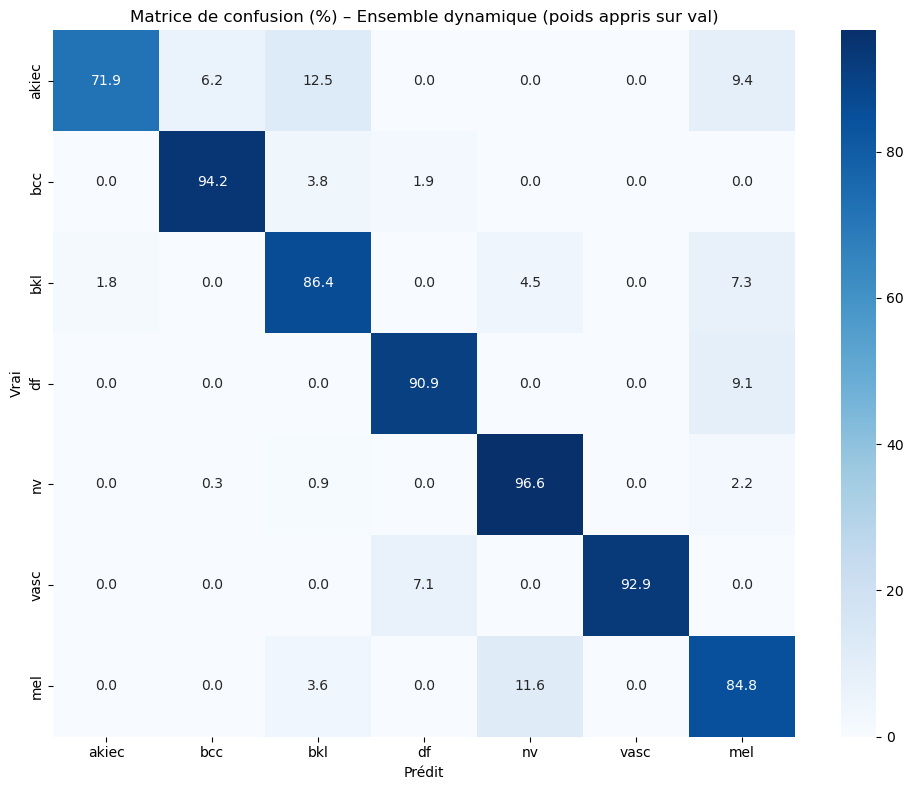

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet

# =======================
# Config & données
# =======================
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
N_CLASSES = len(CLASS_NAMES)
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}

# df et IMAGES_PATH doivent exister dans l'environnement
# On s'assure que df ne contient que les classes ciblées et qu'il a path + label
df = df[df['dx'].isin(CLASS_NAMES)].copy()
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
df['label'] = df['dx'].map(label_to_index)

from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# =======================
# Modèles
# =======================
# Remplace les chemins par les tiens

model_xception_path   = "Protocole-S-V2-Xception-phaseSansTAG-valACC.keras"
model_resnet50_path   = "/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras"
model_densenet201_path= "Protocole-S-V2-Densenet201-Phase8-11-valAUC.keras"

model_xception   = load_model(model_xception_path, compile=False)
model_resnet50   = load_model(model_resnet50_path, compile=False)
model_densenet201= load_model(model_densenet201_path, compile=False)

# =======================
# I/O images
# =======================
def load_image_paths(paths, target_size):
    """Charge et redimensionne les images en RGB (np.array float32, shape (B,H,W,3))."""
    arr = np.array([
        image.img_to_array(
            image.load_img(p, target_size=target_size, color_mode="rgb")
        ) for p in paths
    ], dtype=np.float32)
    return arr

def batched_preds(model, paths, preprocess_fn, target_size, batch_size=32):
    """Prédictions par batch avec prétraitement adapté au backbone."""
    preds = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        batch = load_image_paths(batch_paths, target_size)
        batch = preprocess_fn(batch)
        preds.append(model.predict(batch, verbose=0))
    return np.vstack(preds)

# =======================
# Métriques par classe (val) -> poids par classe
# =======================
from sklearn.metrics import classification_report

def per_class_f1(y_true_idx, y_pred_probs):
    """Retourne un vecteur f1 par classe (ordre = CLASS_NAMES)."""
    y_pred = np.argmax(y_pred_probs, axis=1)
    rep = classification_report(
        y_true_idx, y_pred,
        labels=np.arange(N_CLASSES),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
    f1 = np.array([rep[name]['f1-score'] for name in CLASS_NAMES], dtype=np.float32)
    return f1, rep

def compute_classwise_weights(val_df, smoothing=1e-3, print_table=True):
    """Calcule des poids par classe pour chaque modèle à partir des F1(val)."""
    y_true_val = val_df['label'].values.astype(int)
    paths_val  = val_df['path'].tolist()

    # Prédictions val pour chaque modèle
    px = batched_preds(model_xception,   paths_val, preprocess_xception, (299,299))
    pr = batched_preds(model_resnet50,   paths_val, preprocess_resnet,   (224,224))
    pdn= batched_preds(model_densenet201,paths_val, preprocess_densenet, (224,224))

    # F1 par classe
    f1_x, rep_x = per_class_f1(y_true_val, px)
    f1_r, rep_r = per_class_f1(y_true_val, pr)
    f1_d, rep_d = per_class_f1(y_true_val, pdn)

    # Empilement + lissage + normalisation par classe (somme des 3 = 1 pour chaque classe)
    W = np.vstack([f1_x + smoothing, f1_r + smoothing, f1_d + smoothing])  # shape (3, 7)
    W /= W.sum(axis=0, keepdims=True)

    weights = {
        'xception':  W[0],   # longueur 7
        'resnet50':  W[1],
        'densenet':  W[2]
    }

    if print_table:
        print("\n=== F1 sur validation (par classe) ===")
        for i, name in enumerate(CLASS_NAMES):
            print(f"{name:>6} | Xcp: {f1_x[i]:.3f}  RN50: {f1_r[i]:.3f}  DN201: {f1_d[i]:.3f}")

        print("\n=== Poids par classe (normalisés, somme=1 par classe) ===")
        for i, name in enumerate(CLASS_NAMES):
            print(f"{name:>6} | Xcp: {weights['xception'][i]:.2f}  RN50: {weights['resnet50'][i]:.2f}  DN201: {weights['densenet'][i]:.2f}")

    return weights, {'xception':rep_x, 'resnet50':rep_r, 'densenet':rep_d}

# =======================
# Ensemble dynamique (test)
# =======================
def predict_ensemble_dynamic(image_paths, weights, batch_size=32):
    preds_all = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Prédiction ensemble (dynamic)"):
        batch_paths = image_paths[i:i+batch_size]

        bx = preprocess_xception(load_image_paths(batch_paths, (299,299)))
        br = preprocess_resnet(load_image_paths(batch_paths, (224,224)))
        bd = preprocess_densenet(load_image_paths(batch_paths, (224,224)))

        px = model_xception.predict(bx, verbose=0)
        pr = model_resnet50.predict(br, verbose=0)
        pd = model_densenet201.predict(bd, verbose=0)

        # Pondération par classe (broadcast colonne par colonne)
        # Chaque matrice (B,7) est multipliée par un vecteur (7,) -> broadcasting sur l'axe des colonnes
        combined = px * weights['xception'] + pr * weights['resnet50'] + pd * weights['densenet']

        preds_all.append(combined)

    probs = np.vstack(preds_all)
    y_pred = np.argmax(probs, axis=1)
    return y_pred, probs

# =======================
# Calibrage des poids (val) puis évaluation (test)
# =======================
print("\n[Calibrage] Calcul des poids par classe à partir du set de validation…")
weights, val_reports = compute_classwise_weights(val_df, smoothing=1e-3, print_table=True)

print("\n[Évaluation] Ensemble dynamique sur le set de test…")
y_true_test = test_df['label'].values.astype(int)
y_pred_test, probs_test = predict_ensemble_dynamic(test_df['path'].tolist(), weights)

print("\nClassification Report (test) :")
print(classification_report(y_true_test, y_pred_test,
                            target_names=CLASS_NAMES,
                            labels=np.arange(N_CLASSES)))

# Matrice de confusion en %
conf_matrix = confusion_matrix(y_true_test, y_pred_test, labels=np.arange(N_CLASSES))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion (%) – Ensemble dynamique (poids appris sur val)')
plt.tight_layout()
plt.show()


## POIDS

## ENSEMBL SUR VALIDATION

✅ Pondérations normalisées par classe :
akiec  → Xception=0.000, ResNet=0.100, DenseNet=0.900
bcc    → Xception=0.900, ResNet=0.050, DenseNet=0.050
bkl    → Xception=0.800, ResNet=0.000, DenseNet=0.200
df     → Xception=0.900, ResNet=0.050, DenseNet=0.050
nv     → Xception=0.500, ResNet=0.100, DenseNet=0.400
vasc   → Xception=0.800, ResNet=0.100, DenseNet=0.100
mel    → Xception=0.000, ResNet=0.050, DenseNet=0.950

📊 Évaluation du modèle d'ensemble pondéré sur le validation set...


Prédiction par batchs: 100%|██████████| 32/32 [01:46<00:00,  3.31s/it]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.69      0.76      0.72        33
         bcc       1.00      0.82      0.90        51
         bkl       0.80      0.81      0.81       110
          df       0.91      0.83      0.87        12
          nv       0.97      0.93      0.95       670
        vasc       0.81      0.93      0.87        14
         mel       0.67      0.85      0.75       111

    accuracy                           0.90      1001
   macro avg       0.84      0.85      0.84      1001
weighted avg       0.91      0.90      0.90      1001



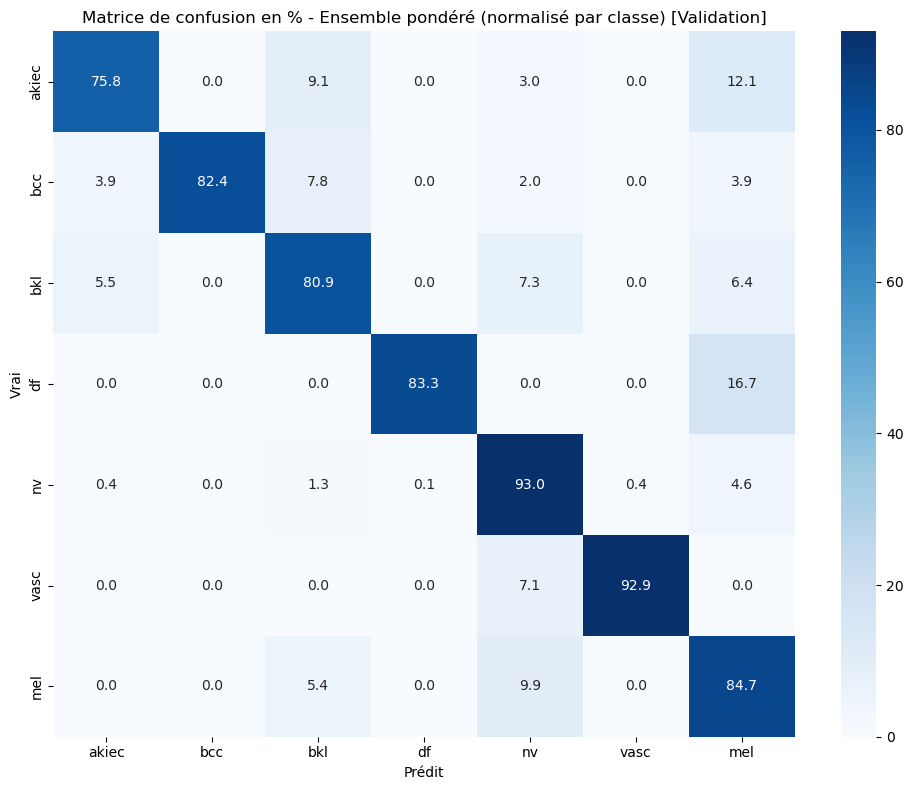

In [21]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet

# ---- Configuration ----
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
N_CLASSES = len(CLASS_NAMES)
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}

# =======================
# Chargement des données
# =======================
df = df[df['dx'].isin(CLASS_NAMES)].copy()
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
df['label'] = df['dx'].map(label_to_index)

val_df = val_df[val_df['dx'].isin(CLASS_NAMES)].copy()
val_df['path'] = val_df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
val_df['label'] = val_df['dx'].map(label_to_index)

# ---- Chargement des modèles ----
model_xcept_big = load_model("Protocole-S-V2-Xception-phaseSansTAG-valACC.keras", compile=False)
model_resnet50  = load_model("/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras", compile=False)
model_densenet201 = load_model("Protocole-S-V2-Densenet201-Phase8-11-valAUC.keras",
                               compile=False,
                               custom_objects={'preprocess_input': preprocess_densenet})

# ---- Préparation des images ----
def load_image_paths(paths, target_size):
    return np.array([
        image.img_to_array(image.load_img(p, target_size=target_size, color_mode="rgb"))
        for p in paths
    ])

# ---- Pondérations brutes (avant normalisation) ----
weights_xception = np.array([0.0,   0.9,  0.8,  0.9,  0.5,  0.8,  0.0])
weights_resnet   = np.array([0.1,   0.05,  0.00, 0.05,  0.1,  0.1,  0.05])
weights_densenet = np.array([0.9,    0.05,  0.2,  0.05,  0.4,  0.1,  0.95])

# ---- Normalisation par classe (colonne) ----
weights = np.vstack([weights_xception, weights_resnet, weights_densenet])  # shape (3,7)
weights /= weights.sum(axis=0, keepdims=True)  # somme = 1 par classe

weights_xception, weights_resnet, weights_densenet = weights

print("✅ Pondérations normalisées par classe :")
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:6s} → Xception={weights_xception[i]:.3f}, ResNet={weights_resnet[i]:.3f}, DenseNet={weights_densenet[i]:.3f}")

# ---- Prédiction en batch avec pondération classe par classe ----
def predict_weighted_ensemble(image_paths, batch_size=32):
    all_preds = []
    num_images = len(image_paths)
    
    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction par batchs"):
        batch_paths = image_paths[i:i + batch_size]

        # Charger images pour chaque modèle
        batch_xcept      = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        batch_resnet     = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))
        batch_densenet   = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))

        # Prédictions brutes
        pred_xcept    = model_xcept_big.predict(batch_xcept, verbose=0)
        pred_resnet   = model_resnet50.predict(batch_resnet, verbose=0)
        pred_densenet = model_densenet201.predict(batch_densenet, verbose=0)

        # Appliquer pondération classe par classe
        final_pred = (
            pred_xcept * weights_xception +
            pred_resnet * weights_resnet +
            pred_densenet * weights_densenet
        )

        all_preds.extend(np.argmax(final_pred, axis=1))
    
    return np.array(all_preds)

# ---- Évaluation ----
print("\n📊 Évaluation du modèle d'ensemble pondéré sur le validation set...")
y_true = val_df['label'].values
y_pred = predict_weighted_ensemble(val_df['path'].tolist())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ---- Matrice de confusion en pourcentage ----
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré (normalisé par classe) [Validation]')
plt.tight_layout()
plt.show()


## ENSEMBLE SUR TEST

✅ Pondérations normalisées par classe :
akiec  → Xception=0.050, ResNet=0.050, DenseNet=0.900
bcc    → Xception=0.800, ResNet=0.100, DenseNet=0.100
bkl    → Xception=0.800, ResNet=0.000, DenseNet=0.200
df     → Xception=0.900, ResNet=0.050, DenseNet=0.050
nv     → Xception=0.500, ResNet=0.100, DenseNet=0.400
vasc   → Xception=0.800, ResNet=0.100, DenseNet=0.100
mel    → Xception=0.050, ResNet=0.150, DenseNet=0.800

📊 Évaluation du modèle d'ensemble pondéré sur le test set...


Prédiction par batchs: 100%|██████████| 32/32 [02:30<00:00,  4.69s/it]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.90      0.81      0.85        32
         bcc       0.94      0.92      0.93        52
         bkl       0.86      0.86      0.86       110
          df       1.00      0.91      0.95        11
          nv       0.97      0.96      0.96       671
        vasc       1.00      1.00      1.00        14
         mel       0.77      0.88      0.82       112

    accuracy                           0.93      1002
   macro avg       0.92      0.91      0.91      1002
weighted avg       0.93      0.93      0.93      1002



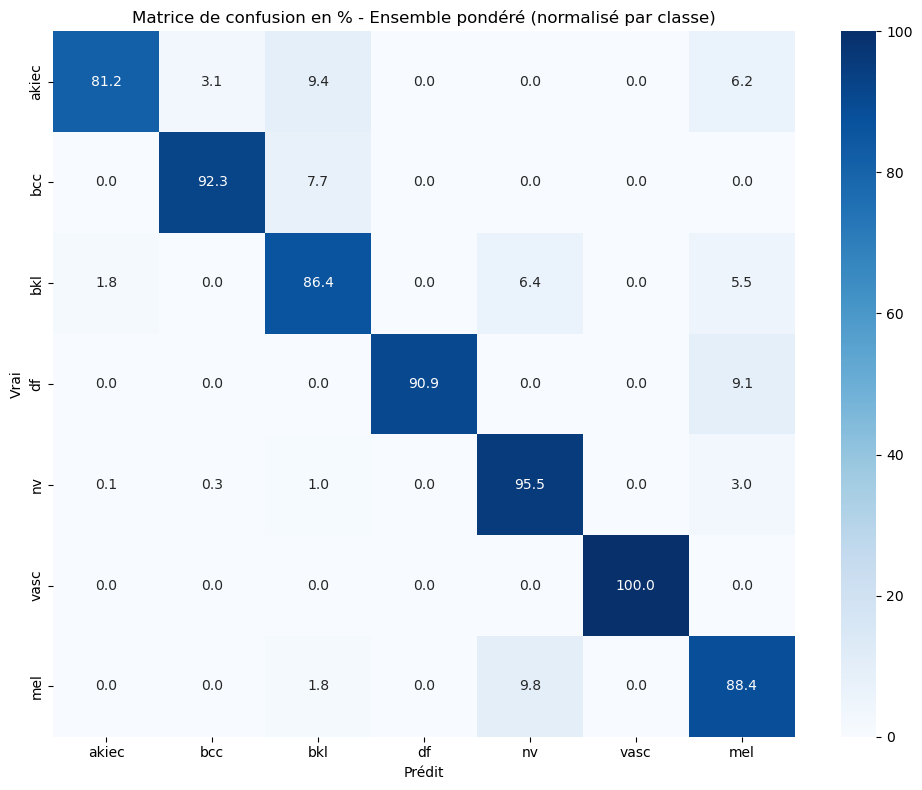

In [55]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet

# ---- Configuration ----
#CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']

# =======================
# Config & données
# =======================
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
N_CLASSES = len(CLASS_NAMES)
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}

# df et IMAGES_PATH doivent exister dans l'environnement
# On s'assure que df ne contient que les classes ciblées et qu'il a path + label
df = df[df['dx'].isin(CLASS_NAMES)].copy()
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
df['label'] = df['dx'].map(label_to_index)

test_df = test_df[test_df['dx'].isin(CLASS_NAMES)].copy()
test_df['path'] = test_df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
test_df['label'] = test_df['dx'].map(label_to_index)


# ---- Chargement des modèles ----

model_xcept_big = load_model("Protocole-S-V2-Xception-phaseSansTAG-valACC.keras", compile=False)
model_resnet50  = load_model("/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras", compile=False)
model_densenet201 = load_model("Protocole-S-V2-Densenet201-Phase8-11-valAUC.keras",
                               compile=False,
                               custom_objects={'preprocess_input': preprocess_densenet})

# ---- Préparation des images ----
def load_image_paths(paths, target_size):
    return np.array([
        image.img_to_array(image.load_img(p, target_size=target_size, color_mode="rgb"))
        for p in paths
    ])

# ---- Pondérations brutes (avant normalisation) ----
#                            akiec  bcc   bkl   df    nv    vasc  mel
weights_xception = np.array([0.05,   0.8,  0.8,  0.9,  0.5,  0.8,  0.05])
weights_resnet   = np.array([0.05,   0.1,  0.00,  0.05,  0.1,  0.1,  0.15])
weights_densenet = np.array([0.9,   0.1,  0.2,  0.05,  0.4,  0.1,  0.8])

# ---- Normalisation par classe (colonne) ----
weights = np.vstack([weights_xception, weights_resnet, weights_densenet])  # shape (3,7)
weights /= weights.sum(axis=0, keepdims=True)  # somme = 1 par classe

weights_xception, weights_resnet, weights_densenet = weights

print("✅ Pondérations normalisées par classe :")
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:6s} → Xception={weights_xception[i]:.3f}, ResNet={weights_resnet[i]:.3f}, DenseNet={weights_densenet[i]:.3f}")

# ---- Prédiction en batch avec pondération classe par classe ----
def predict_weighted_ensemble(image_paths, batch_size=32):
    all_preds = []
    num_images = len(image_paths)
    
    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction par batchs"):
        batch_paths = image_paths[i:i + batch_size]

        # Charger images pour chaque modèle
        batch_xcept      = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        batch_resnet     = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))
        batch_densenet   = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))

        # Prédictions brutes
        pred_xcept    = model_xcept_big.predict(batch_xcept, verbose=0)
        pred_resnet   = model_resnet50.predict(batch_resnet, verbose=0)
        pred_densenet = model_densenet201.predict(batch_densenet, verbose=0)

        # Appliquer pondération classe par classe
        final_pred = (
            pred_xcept * weights_xception +
            pred_resnet * weights_resnet +
            pred_densenet * weights_densenet
        )

        all_preds.extend(np.argmax(final_pred, axis=1))
    
    return np.array(all_preds)

# ---- Évaluation ----
print("\n📊 Évaluation du modèle d'ensemble pondéré sur le test set...")
y_true = test_df['label'].values
y_pred = predict_weighted_ensemble(test_df['path'].tolist())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ---- Matrice de confusion en pourcentage ----
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré (normalisé par classe)')
plt.tight_layout()
plt.show()


## GRID SEARCH SUR VAL Display aussi average specificity et average AUC

Prédictions modèles: 100%|██████████| 32/32 [01:30<00:00,  2.84s/it]



🔎 Top 10 combinaisons (triées par recall macro) :
 Xception  ResNet  DenseNet  avg_recall  avg_specificity  avg_auc
   0.5000  0.2500    0.2500      0.8855           0.9809   0.9761
   0.7500  0.0000    0.2500      0.8833           0.9807   0.9908
   0.7500  0.2500    0.0000      0.8790           0.9802   0.9655
   1.0000  0.0000    0.0000      0.8790           0.9805   0.9881
   0.5000  0.5000    0.0000      0.8744           0.9787   0.9625
   0.5000  0.0000    0.5000      0.8716           0.9798   0.9901
   0.2500  0.2500    0.5000      0.8080           0.9753   0.9750
   0.2500  0.0000    0.7500      0.7996           0.9740   0.9885
   0.2500  0.5000    0.2500      0.7768           0.9710   0.9728
   0.0000  0.0000    1.0000      0.7756           0.9718   0.9788

✅ Meilleurs poids trouvés : Xception=0.50, ResNet=0.25, DenseNet=0.25
→ Avg Recall=0.8855, Avg Specificity=0.9809, Avg AUC=0.9761

📊 Rapport de classification (validation set avec meilleurs poids)...


Prédictions modèles: 100%|██████████| 32/32 [00:31<00:00,  1.01it/s]

              precision    recall  f1-score   support

       akiec       0.90      0.79      0.84        33
         bcc       1.00      0.82      0.90        51
         bkl       0.82      0.86      0.84       110
          df       0.92      1.00      0.96        12
          nv       0.96      0.96      0.96       670
        vasc       0.87      0.93      0.90        14
         mel       0.77      0.84      0.80       111

    accuracy                           0.92      1001
   macro avg       0.89      0.89      0.89      1001
weighted avg       0.92      0.92      0.92      1001



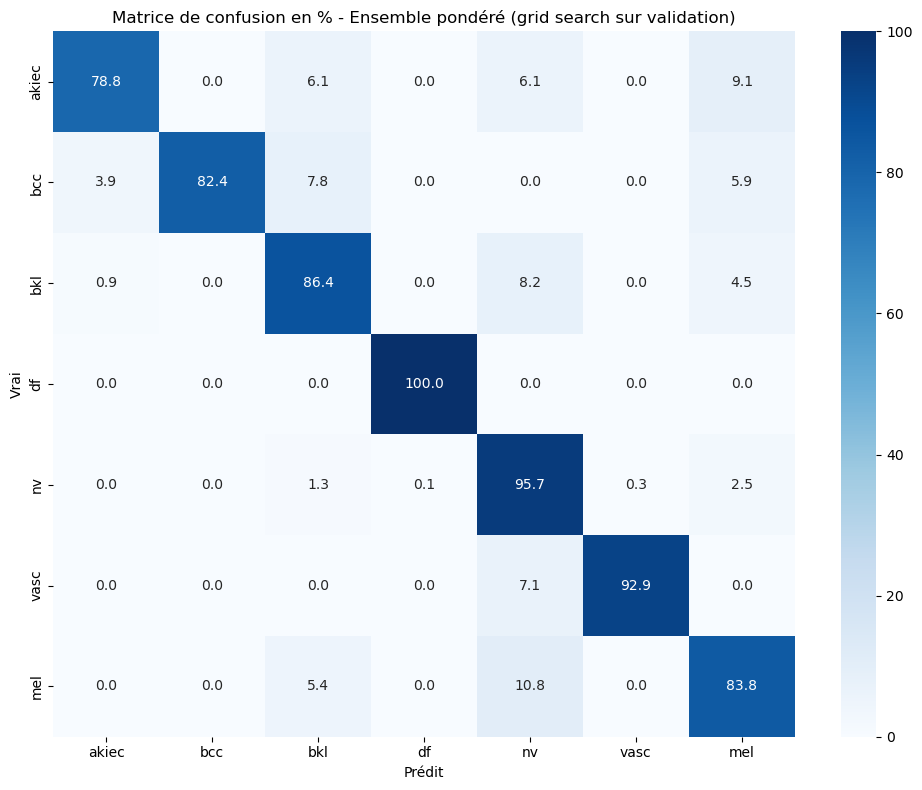

In [16]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, recall_score, roc_auc_score
from tqdm import tqdm
import itertools

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet

# ---- Configuration ----
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
N_CLASSES = len(CLASS_NAMES)
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}

# =======================
# Chargement des données
# =======================
val_df = val_df[val_df['dx'].isin(CLASS_NAMES)].copy()
val_df['path'] = val_df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
val_df['label'] = val_df['dx'].map(label_to_index)

# ---- Chargement des modèles ----
model_xcept_big = load_model("Protocole-S-V2-Xception-phaseSansTAG-valACC.keras", compile=False)
model_resnet50  = load_model("/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras", compile=False)
model_densenet201 = load_model("Protocole-S-V2-Densenet201-Phase8-11-valAUC.keras",
                               compile=False,
                               custom_objects={'preprocess_input': preprocess_densenet})

# ---- Préparation des images ----
def load_image_paths(paths, target_size):
    return np.array([
        image.img_to_array(image.load_img(p, target_size=target_size, color_mode="rgb"))
        for p in paths
    ])

# ---- Prédiction en batch ----
def predict_models(image_paths, batch_size=32):
    preds_xcept, preds_resnet, preds_densenet = [], [], []
    num_images = len(image_paths)

    for i in tqdm(range(0, num_images, batch_size), desc="Prédictions modèles"):
        batch_paths = image_paths[i:i + batch_size]

        batch_xcept      = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        batch_resnet     = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))
        batch_densenet   = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))

        preds_xcept.append(model_xcept_big.predict(batch_xcept, verbose=0))
        preds_resnet.append(model_resnet50.predict(batch_resnet, verbose=0))
        preds_densenet.append(model_densenet201.predict(batch_densenet, verbose=0))

    return np.vstack(preds_xcept), np.vstack(preds_resnet), np.vstack(preds_densenet)

# ---- Calcul des métriques ----
def compute_metrics(y_true, y_pred, y_proba, class_names=CLASS_NAMES):
    n_classes = len(class_names)
    
    # Recall (sensibilité)
    recalls = recall_score(y_true, y_pred, average=None, labels=np.arange(n_classes))
    avg_recall = recalls.mean()
    
    # Specificity (par confusion matrix)
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
    specificities = []
    for i in range(n_classes):
        TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        FP = cm[:, i].sum() - cm[i, i]
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        specificities.append(specificity)
    avg_specificity = np.mean(specificities)
    
    # AUC
    y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=n_classes)
    avg_auc = roc_auc_score(y_true_onehot, y_proba, average="macro", multi_class="ovr")
    
    return {
        "avg_recall": avg_recall,
        "avg_specificity": avg_specificity,
        "avg_auc": avg_auc,
        "recalls_per_class": dict(zip(class_names, recalls)),
        "specificity_per_class": dict(zip(class_names, specificities))
    }

# ---- Évaluation pour un triplet de poids ----
def evaluate_ensemble(y_true, preds, weights):
    pred_xcept, pred_resnet, pred_densenet = preds
    y_proba = (
        pred_xcept * weights[0] +
        pred_resnet * weights[1] +
        pred_densenet * weights[2]
    )
    y_pred = np.argmax(y_proba, axis=1)
    
    metrics = compute_metrics(y_true, y_pred, y_proba, CLASS_NAMES)
    
    # 🔑 La métrique d’optimisation principale = avg_recall
    return metrics["avg_recall"], metrics

# ---- Grid search ----
def grid_search_weights(val_df, step=0.25):
    y_true = val_df['label'].values
    preds = predict_models(val_df['path'].tolist())
    
    search_space = np.arange(0, 1.01, step)
    results = []

    for w in itertools.product(search_space, repeat=3):
        if abs(sum(w) - 1.0) > 1e-6:  # impose somme=1
            continue
        score, metrics = evaluate_ensemble(y_true, preds, w)
        results.append({
            "Xception": w[0], "ResNet": w[1], "DenseNet": w[2],
            "avg_recall": metrics["avg_recall"],
            "avg_specificity": metrics["avg_specificity"],
            "avg_auc": metrics["avg_auc"]
        })

    # Résultats triés par avg_recall décroissant
    df_results = pd.DataFrame(results).sort_values(by="avg_recall", ascending=False)
    
    best_row = df_results.iloc[0]
    print("\n🔎 Top 10 combinaisons (triées par recall macro) :")
    print(df_results.head(10).to_string(index=False, float_format="%.4f"))
    
    print(f"\n✅ Meilleurs poids trouvés : Xception={best_row['Xception']:.2f}, "
          f"ResNet={best_row['ResNet']:.2f}, DenseNet={best_row['DenseNet']:.2f}")
    print(f"→ Avg Recall={best_row['avg_recall']:.4f}, "
          f"Avg Specificity={best_row['avg_specificity']:.4f}, "
          f"Avg AUC={best_row['avg_auc']:.4f}")
    
    return best_row[["Xception","ResNet","DenseNet"]].values, df_results

# ---- Lancement grid search ----
best_weights, df_results = grid_search_weights(val_df, step=0.25)

# ---- Évaluation finale avec ces poids ----
print("\n📊 Rapport de classification (validation set avec meilleurs poids)...")
y_true = val_df['label'].values
preds = predict_models(val_df['path'].tolist())
pred_final = (
    preds[0] * best_weights[0] +
    preds[1] * best_weights[1] +
    preds[2] * best_weights[2]
)
y_pred = np.argmax(pred_final, axis=1)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ---- Matrice de confusion ----
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré (grid search sur validation)')
plt.tight_layout()
plt.show()


In [56]:
def predict_weighted_ensemble_probs(image_paths, batch_size=32):
    all_preds = []
    num_images = len(image_paths)
    
    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction par batchs"):
        batch_paths = image_paths[i:i + batch_size]

        batch_xcept    = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        batch_resnet   = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))
        batch_densenet = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))

        pred_xcept    = model_xcept_big.predict(batch_xcept, verbose=0)
        pred_resnet   = model_resnet50.predict(batch_resnet, verbose=0)
        pred_densenet = model_densenet201.predict(batch_densenet, verbose=0)

        final_pred = (
            pred_xcept * weights_xception +
            pred_resnet * weights_resnet +
            pred_densenet * weights_densenet
        )

        all_preds.append(final_pred)
    
    return np.vstack(all_preds)  # shape (num_images, num_classes)


Prédiction proba par batchs: 100%|██████████| 32/32 [00:31<00:00,  1.02it/s]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.90      0.81      0.85        32
         bcc       0.94      0.92      0.93        52
         bkl       0.86      0.86      0.86       110
          df       1.00      0.91      0.95        11
          nv       0.97      0.96      0.96       671
        vasc       1.00      1.00      1.00        14
         mel       0.77      0.88      0.82       112

    accuracy                           0.93      1002
   macro avg       0.92      0.91      0.91      1002
weighted avg       0.93      0.93      0.93      1002



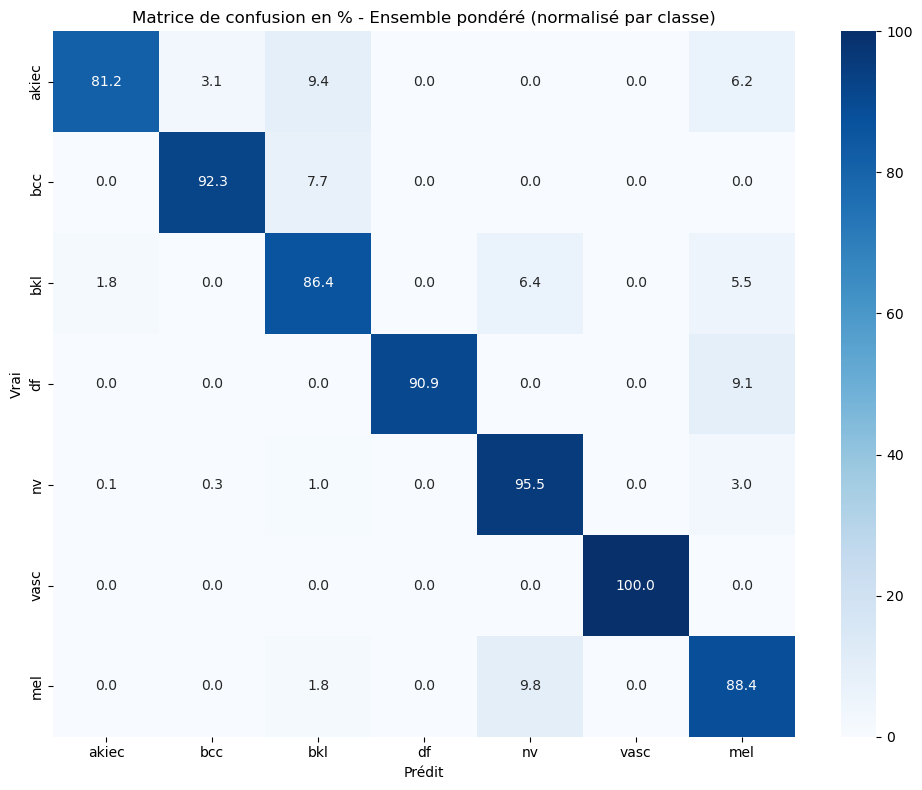


📊 Spécificité par classe:
akiec  : 0.997
bcc    : 0.997
bkl    : 0.982
df     : 1.000
nv     : 0.946
vasc   : 1.000
mel    : 0.967

📊 AUC par classe:
akiec  : 0.961
bcc    : 0.998
bkl    : 0.984
df     : 1.000
nv     : 0.987
vasc   : 1.000
mel    : 0.965

Macro AUC : 0.985
Micro AUC : 0.990


In [61]:
from sklearn.metrics import roc_auc_score, roc_curve

# ---- Fonction pour évaluer avec proba au lieu d'argmax ----
def predict_weighted_ensemble_proba(image_paths, batch_size=32):
    all_preds = []
    num_images = len(image_paths)
    
    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction proba par batchs"):
        batch_paths = image_paths[i:i + batch_size]

        # Charger images
        batch_xcept      = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        batch_resnet     = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))
        batch_densenet   = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))

        # Prédictions brutes
        pred_xcept    = model_xcept_big.predict(batch_xcept, verbose=0)
        pred_resnet   = model_resnet50.predict(batch_resnet, verbose=0)
        pred_densenet = model_densenet201.predict(batch_densenet, verbose=0)

        # Appliquer pondérations par classe
        final_pred = (
            pred_xcept * weights_xception +
            pred_resnet * weights_resnet +
            pred_densenet * weights_densenet
        )

        all_preds.append(final_pred)
    
    return np.vstack(all_preds)

# ---- Évaluation avec proba ----
y_true = test_df['label'].values
y_pred_proba = predict_weighted_ensemble_proba(test_df['path'].tolist())
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ---- Matrice de confusion ----
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré (normalisé par classe)')
plt.tight_layout()
plt.show()

# ---- Spécificité par classe ----
specificities = {}
for i, cls in enumerate(CLASS_NAMES):
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificities[cls] = specificity

print("\n📊 Spécificité par classe:")
for cls, spec in specificities.items():
    print(f"{cls:6s} : {spec:.3f}")

# ---- ROC / AUC ----
y_true_bin = tf.keras.utils.to_categorical(y_true, num_classes=len(CLASS_NAMES))

roc_auc = {}
for i, cls in enumerate(CLASS_NAMES):
    try:
        roc_auc[cls] = roc_auc_score(y_true_bin[:, i], y_pred_proba[:, i])
    except ValueError:
        roc_auc[cls] = np.nan  # si classe absente

print("\n📊 AUC par classe:")
for cls, auc in roc_auc.items():
    print(f"{cls:6s} : {auc:.3f}")

# Macro & micro AUC
macro_auc = roc_auc_score(y_true_bin, y_pred_proba, average="macro", multi_class="ovr")
micro_auc = roc_auc_score(y_true_bin, y_pred_proba, average="micro", multi_class="ovr")

print(f"\nMacro AUC : {macro_auc:.3f}")
print(f"Micro AUC : {micro_auc:.3f}")


Prédiction par batchs: 100%|██████████| 32/32 [00:32<00:00,  1.00s/it]


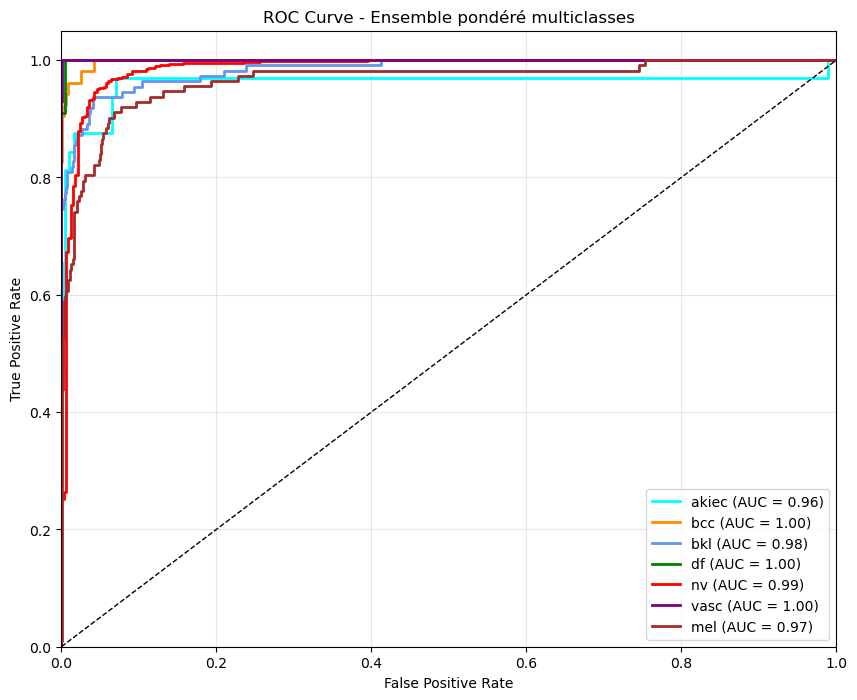

In [57]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Probabilités finales
y_scores = predict_weighted_ensemble_probs(test_df['path'].tolist())
y_true_bin = label_binarize(y_true, classes=np.arange(len(CLASS_NAMES)))  # shape (num_images, 7)

# Calcul FPR, TPR et AUC pour chaque classe
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(CLASS_NAMES)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Tracer
plt.figure(figsize=(10,8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown'])
for i, color in zip(range(len(CLASS_NAMES)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Ensemble pondéré multiclasses')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [63]:
optimal_thresholds = {}
for i in range(len(CLASS_NAMES)):
    thresholds = np.linspace(0, 1, 100)
    f1_scores = []
    for t in thresholds:
        y_pred_class = (y_scores[:, i] >= t).astype(int)
        tp = np.sum((y_true_bin[:, i] == 1) & (y_pred_class == 1))
        fp = np.sum((y_true_bin[:, i] == 0) & (y_pred_class == 1))
        fn = np.sum((y_true_bin[:, i] == 1) & (y_pred_class == 0))
        f1 = 2*tp / (2*tp + fp + fn + 1e-8)
        f1_scores.append(f1)
    optimal_thresholds[CLASS_NAMES[i]] = thresholds[np.argmax(f1_scores)]

print("✅ Seuils optimaux par classe :")
for cls, t in optimal_thresholds.items():
    print(f"{cls:6s} → {t:.3f}")


✅ Seuils optimaux par classe :
akiec  → 0.485
bcc    → 0.414
bkl    → 0.778
df     → 0.374
nv     → 0.364
vasc   → 0.111
mel    → 0.727


In [62]:
# ---- Spécificité globale ----
macro_specificity = np.mean(list(specificities.values()))

# Micro = somme TN / (TN + FP) global
TN_total, FP_total = 0, 0
for i in range(len(CLASS_NAMES)):
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    TN_total += tn
    FP_total += fp
micro_specificity = TN_total / (TN_total + FP_total)

print(f"\n📊 Spécificité globale (macro) : {macro_specificity:.3f}")
print(f"📊 Spécificité globale (micro) : {micro_specificity:.3f}")



📊 Spécificité globale (macro) : 0.984
📊 Spécificité globale (micro) : 0.989


In [64]:
from sklearn.metrics import roc_auc_score, confusion_matrix

# ---- Fonction de calcul des métriques ISIC 2018 ----
def compute_official_metrics(y_true, y_pred, y_prob, class_names):
    n_classes = len(class_names)
    mel_idx = class_names.index('mel')
    conf = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))

    metrics = {}

    # 1) Balanced Multiclass Accuracy = Macro-average recall
    recalls = np.diag(conf) / conf.sum(axis=1, where=conf.sum(axis=1)!=0)
    metrics["BCMA"] = np.nanmean(recalls)

    # 2) Sensitivity for Melanoma
    TP = conf[mel_idx, mel_idx]
    FN = conf[mel_idx, :].sum() - TP
    metrics["Sens_mel"] = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    # 3) Average AUC (one-vs-rest)
    aucs = []
    for c in range(n_classes):
        if np.sum(y_true == c) > 0:  # skip empty classes
            y_true_bin = (y_true == c).astype(int)
            aucs.append(roc_auc_score(y_true_bin, y_prob[:, c]))
    metrics["Avg_AUC"] = np.mean(aucs)

    # 4) Average Specificity
    specs = []
    for c in range(n_classes):
        TN = conf.sum() - (conf[c, :].sum() + conf[:, c].sum() - conf[c, c])
        FP = conf[:, c].sum() - conf[c, c]
        specs.append(TN / (TN + FP) if (TN + FP) > 0 else np.nan)
    metrics["Avg_Spec"] = np.nanmean(specs)

    return metrics

# ---- On modifie la fonction d’ensemble pour renvoyer AUSSI les probabilités ----
def predict_weighted_ensemble(image_paths, batch_size=32):
    all_preds = []
    all_probs = []
    num_images = len(image_paths)
   
    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction par batchs"):
        batch_paths = image_paths[i:i + batch_size]

        # Charger images pour chaque modèle
        batch_xcept      = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        batch_resnet     = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))
        batch_densenet   = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))

        # Prédictions brutes
        pred_xcept    = model_xcept_big.predict(batch_xcept, verbose=0)
        pred_resnet   = model_resnet50.predict(batch_resnet, verbose=0)
        pred_densenet = model_densenet201.predict(batch_densenet, verbose=0)

        # Appliquer pondération classe par classe
        final_pred = (
            pred_xcept * weights_xception +
            pred_resnet * weights_resnet +
            pred_densenet * weights_densenet
        )

        all_probs.append(final_pred)
        all_preds.extend(np.argmax(final_pred, axis=1))
   
    return np.array(all_preds), np.vstack(all_probs)

# ---- Évaluation ----
print("\n📊 Évaluation du modèle d'ensemble pondéré sur le test set...")
y_true = test_df['label'].values
y_pred, y_prob = predict_weighted_ensemble(test_df['path'].tolist())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ---- Métriques officielles ISIC 2018 ----
results = compute_official_metrics(y_true, y_pred, y_prob, CLASS_NAMES)
print("\n📊 Résultats style ISIC 2018 :")
for k, v in results.items():
    print(f"{k:12s} = {v:.3f}")


📊 Évaluation du modèle d'ensemble pondéré sur le test set...


Prédiction par batchs: 100%|██████████| 32/32 [00:30<00:00,  1.04it/s]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.90      0.81      0.85        32
         bcc       0.94      0.92      0.93        52
         bkl       0.86      0.86      0.86       110
          df       1.00      0.91      0.95        11
          nv       0.97      0.96      0.96       671
        vasc       1.00      1.00      1.00        14
         mel       0.77      0.88      0.82       112

    accuracy                           0.93      1002
   macro avg       0.92      0.91      0.91      1002
weighted avg       0.93      0.93      0.93      1002


📊 Résultats style ISIC 2018 :
BCMA         = 0.907
Sens_mel     = 0.884
Avg_AUC      = 0.985
Avg_Spec     = 0.984



Évaluation du modèle d'ensemble pondéré par classe sur l'ensemble de test...


Prédiction par batchs: 100%|██████████| 32/32 [01:26<00:00,  2.69s/it]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.96      0.78      0.86        32
         bcc       1.00      0.44      0.61        52
         bkl       0.86      0.82      0.84       110
          df       0.89      0.73      0.80        11
          nv       0.93      0.97      0.95       671
        vasc       1.00      0.86      0.92        14
         mel       0.77      0.88      0.82       112

    accuracy                           0.90      1002
   macro avg       0.91      0.78      0.83      1002
weighted avg       0.91      0.90      0.90      1002



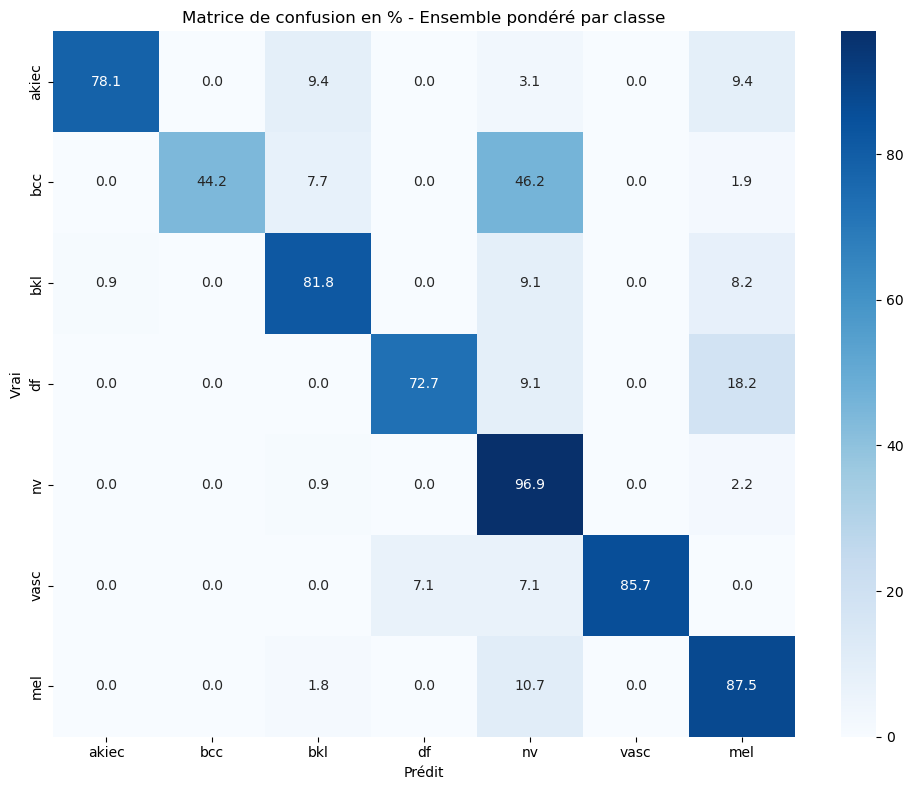

In [22]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inception
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet

# ---- Configuration ----
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']

# ---- Chargement des modèles ----

model_xcept_big   = load_model("Protocole-S-V2-Xception-phaseSansTAG-valACC.keras", compile=False)
model_resnet50 = load_model("/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras", compile=False)
model_densenet201 = load_model("Protocole-S-V2-Densenet201-Phase8-11-valAUC.keras", compile=False, custom_objects={'preprocess_input': preprocess_densenet})

# ---- Préparation des images ----
def load_image_paths(paths, target_size):
    return np.array([
        image.img_to_array(image.load_img(p, target_size=target_size, color_mode="rgb"))
        for p in paths
    ])

# ---- Pondérations par modèle et par classe ----
# Chaque ligne = poids (Xception, ResNet, DenseNet) pour cette classe
class_weights = np.array([
    [0.8, 0.1, 0.1],  # akiec
    [0.1, 0.8, 0.1],  # bcc
    [0.5, 0.2, 0.3],  # bkl
    [0.5, 0.3, 0.2],  # df
    [0.3, 0.4, 0.3],  # nv
    [0.3, 0.3, 0.4],  # vasc
    [0.2, 0.3, 0.5],  # mel
])

# ---- Prédiction en batch avec pondération par classe ----
def predict_ensemble_by_class(image_paths, batch_size=32):
    all_preds = []
    num_images = len(image_paths)
    
    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction par batchs"):
        batch_paths = image_paths[i:i + batch_size]

        # Charger images pour chaque modèle
        batch_xcept    = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        batch_resnet   = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))
        batch_densenet = preprocess_densenet(load_image_paths(batch_paths, (224, 224)))

        # Prédictions brutes
        pred_xcept  = model_xcept_big.predict(batch_xcept, verbose=0)
        pred_resnet = model_resnet50.predict(batch_resnet, verbose=0)
        pred_densenet = model_densenet201.predict(batch_densenet, verbose=0)

        # Pondération par classe
        final_pred = np.zeros_like(pred_xcept)
        for c in range(len(CLASS_NAMES)):
            final_pred[:, c] = (
                pred_xcept[:, c] * class_weights[c, 0] +
                pred_resnet[:, c] * class_weights[c, 1] +
                pred_densenet[:, c] * class_weights[c, 2]
            )
        
        # Choisir la classe prédite
        all_preds.extend(np.argmax(final_pred, axis=1))
    
    return np.array(all_preds)

# ---- Évaluation ----
print("\nÉvaluation du modèle d'ensemble pondéré par classe sur l'ensemble de test...")
y_true = test_df['label'].values
y_pred = predict_ensemble_by_class(test_df['path'].tolist())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ---- Matrice de confusion en pourcentage ----
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré par classe')
plt.tight_layout()
plt.show()



Évaluation de l'ensemble pondéré (Xception + ResNet50 + EfficientNetV2Small)...


Prédiction par batchs: 100%|██████████| 32/32 [01:07<00:00,  2.10s/it]


Classification Report:
              precision    recall  f1-score   support

       akiec       1.00      0.66      0.79        32
         bcc       0.96      0.88      0.92        52
         bkl       0.86      0.85      0.85       110
          df       1.00      0.91      0.95        11
          nv       0.98      0.91      0.94       671
        vasc       1.00      1.00      1.00        14
         mel       0.57      0.92      0.70       112

    accuracy                           0.89      1002
   macro avg       0.91      0.87      0.88      1002
weighted avg       0.92      0.89      0.90      1002



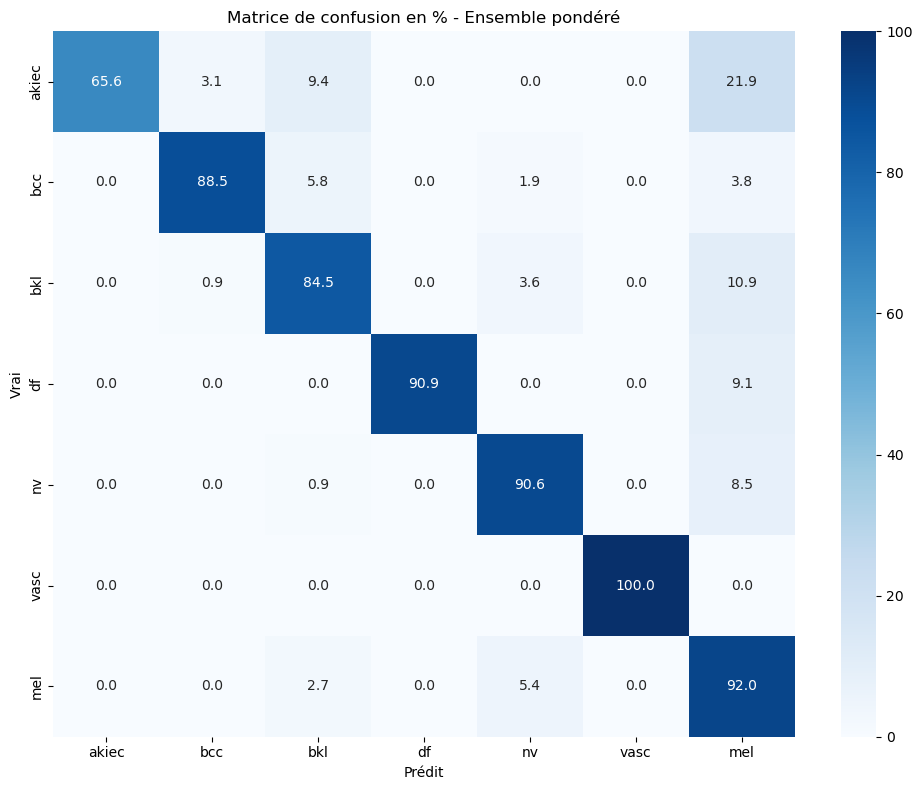

In [17]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as preprocess_efficientnet

# ---- Configuration ----
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}

# ---- DataFrame df supposé dispo ----
df = df[df['dx'].isin(CLASS_NAMES)]
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
df['label'] = df['dx'].map(label_to_index)

# Split train/val/test
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# ---- Chargement des modèles ----
model_xcept    = load_model("Protocole-S-V2-Xception-phaseSansTAG-valACC.keras", compile=False)
model_resnet50 = load_model("/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras", compile=False)
model_effnet = load_model(
    "Protocole-S-V3-efficientNetSMALL-ph4ClassW3-valAUC.keras",
    compile=False,
    custom_objects={"preprocess_input": preprocess_efficientnet}
)

# ---- Préparation images ----
def load_image_paths(paths, target_size):
    return np.array([
        image.img_to_array(
            image.load_img(p, target_size=target_size, color_mode="rgb")
        ) for p in paths
    ])

# ---- Prédiction en batch avec priorisation EfficientNetV2Small sur mel ----
# weights=(0.45, 0.25, 0.30) -> Xception, ResNet50, EffNetV2Small
def predict_ensemble(image_paths, batch_size=32, weights=(0.45, 0.20, 0.35)):
    """
    weights = (w_xception, w_resnet50, w_effnet)
    """
    num_images = len(image_paths)
    all_predictions = []

    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction par batchs"):
        batch_paths = image_paths[i:i + batch_size]

        # Chargement images adaptées
        bx = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        br = preprocess_resnet(load_image_paths(batch_paths, (224, 224)))
        be = preprocess_efficientnet(load_image_paths(batch_paths, (384, 384)))

        # Prédictions
        pred_x = model_xcept.predict(bx, verbose=0)
        pred_r = model_resnet50.predict(br, verbose=0)
        pred_e = model_effnet.predict(be, verbose=0)

        # Moyenne pondérée
        preds = (weights[0] * pred_x +
                 weights[1] * pred_r +
                 weights[2] * pred_e)

        # --- ASTUCE : privilégier EffNetV2Small pour 'mel' (classe index 6) ---
        mel_idx = label_to_index['mel']
        preds[:, mel_idx] = (0.5 * preds[:, mel_idx] + 0.5 * pred_e[:, mel_idx])

        all_predictions.extend(np.argmax(preds, axis=1))

    return np.array(all_predictions)

# ---- Évaluation ----
print("\nÉvaluation de l'ensemble pondéré (Xception + ResNet50 + EfficientNetV2Small)...")

y_true = test_df['label'].values
y_pred = predict_ensemble(test_df['path'].tolist())

print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                            target_names=CLASS_NAMES,
                            labels=np.arange(len(CLASS_NAMES))))

# ---- Matrice de confusion en % ----
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré')
plt.tight_layout()
plt.show()


In [ ]:
Protocole-S-V3-efficientNetSMALL-ph4ClassW6-valAUC.keras


Évaluation de l'ensemble pondéré (Xception + ResNet50 + EfficientNetV2Small)...


Prédiction par batchs: 100%|██████████| 32/32 [01:03<00:00,  1.97s/it]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.83      0.75      0.79        32
         bcc       0.92      0.90      0.91        52
         bkl       0.84      0.88      0.86       110
          df       0.85      1.00      0.92        11
          nv       0.99      0.89      0.93       671
        vasc       1.00      0.86      0.92        14
         mel       0.59      0.94      0.72       112

    accuracy                           0.89      1002
   macro avg       0.86      0.89      0.86      1002
weighted avg       0.91      0.89      0.90      1002



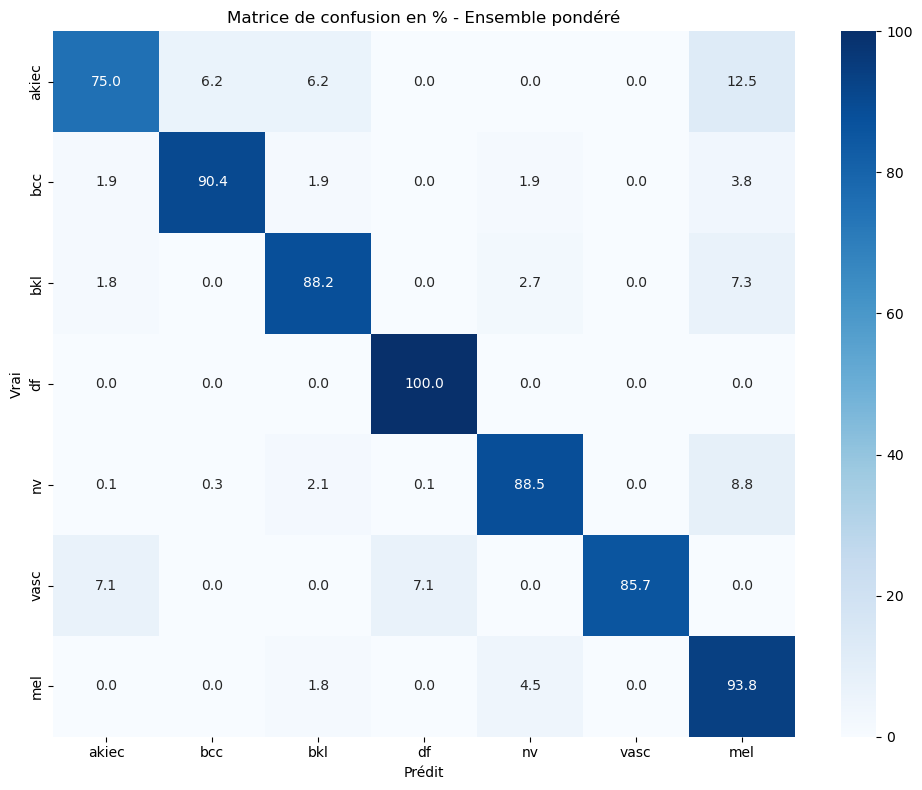

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as preprocess_efficientnet

# ---- Configuration ----
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}

# ---- DataFrame df supposé dispo ----
df = df[df['dx'].isin(CLASS_NAMES)]
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
df['label'] = df['dx'].map(label_to_index)

# Split train/val/test
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# ---- Chargement des modèles ----
model_xcept    = load_model("Protocole-S-V2-Xception-phaseSansTAG-valACC.keras", compile=False)
model_resnet50 = load_model("/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras", compile=False)
model_effnet = load_model(
    "Protocole-S-V3-efficientNetSMALL-ph4ClassW7-valAUC.keras",
    compile=False,
    custom_objects={"preprocess_input": preprocess_efficientnet}
)

# ---- Préparation images ----
def load_image_paths(paths, target_size):
    return np.array([
        image.img_to_array(
            image.load_img(p, target_size=target_size, color_mode="rgb")
        ) for p in paths
    ])

# ---- Prédiction en batch avec priorisation EfficientNetV2Small sur mel ----
# weights=(0.45, 0.25, 0.30) -> Xception, ResNet50, EffNetV2Small
def predict_ensemble(image_paths, batch_size=32, weights=(0.30, 0.20, 0.50)):
    """
    weights = (w_xception, w_resnet50, w_effnet)
    """
    num_images = len(image_paths)
    all_predictions = []

    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction par batchs"):
        batch_paths = image_paths[i:i + batch_size]

        # Chargement images adaptées
        bx = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        br = preprocess_resnet(load_image_paths(batch_paths, (224, 224)))
        be = preprocess_efficientnet(load_image_paths(batch_paths, (384, 384)))

        # Prédictions
        pred_x = model_xcept.predict(bx, verbose=0)
        pred_r = model_resnet50.predict(br, verbose=0)
        pred_e = model_effnet.predict(be, verbose=0)

        # Moyenne pondérée
        preds = (weights[0] * pred_x +
                 weights[1] * pred_r +
                 weights[2] * pred_e)

        # --- ASTUCE : privilégier EffNetV2Small pour 'mel' (classe index 6) ---
        mel_idx = label_to_index['mel']
        preds[:, mel_idx] = (0.5 * preds[:, mel_idx] + 0.5 * pred_e[:, mel_idx])

        all_predictions.extend(np.argmax(preds, axis=1))

    return np.array(all_predictions)

# ---- Évaluation ----
print("\nÉvaluation de l'ensemble pondéré (Xception + ResNet50 + EfficientNetV2Small)...")

y_true = test_df['label'].values
y_pred = predict_ensemble(test_df['path'].tolist())

print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                            target_names=CLASS_NAMES,
                            labels=np.arange(len(CLASS_NAMES))))

# ---- Matrice de confusion en % ----
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré')
plt.tight_layout()
plt.show()


2025-08-30 14:27:47.320758: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-08-30 14:27:47.320788: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-08-30 14:27:47.320794: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1756556867.320806   10191 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1756556867.320824   10191 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



Évaluation de l'ensemble pondéré (Xception + ResNet50 + EfficientNetV2Small)...


Prédiction par batchs: 100%|██████████| 32/32 [01:00<00:00,  1.90s/it]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.79      0.69      0.73        32
         bcc       0.94      0.90      0.92        52
         bkl       0.85      0.85      0.85       110
          df       0.83      0.91      0.87        11
          nv       0.99      0.91      0.95       671
        vasc       0.86      0.86      0.86        14
         mel       0.60      0.93      0.73       112

    accuracy                           0.90      1002
   macro avg       0.84      0.86      0.84      1002
weighted avg       0.92      0.90      0.90      1002



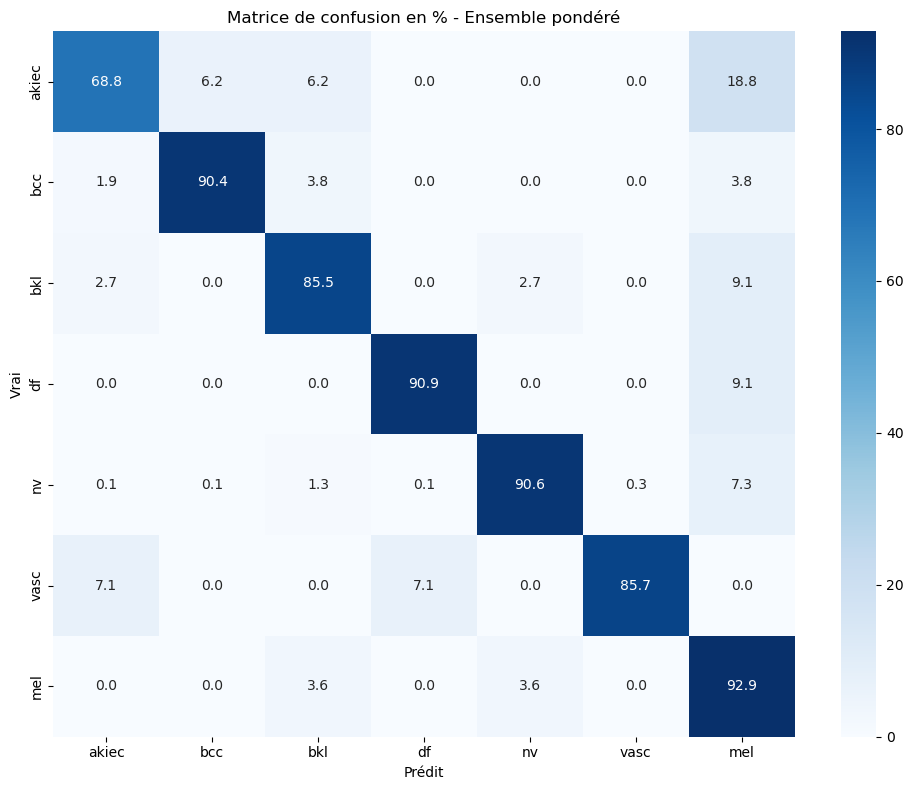

In [6]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as preprocess_efficientnet

# ---- Configuration ----
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}

# ---- DataFrame df supposé dispo ----
df = df[df['dx'].isin(CLASS_NAMES)]
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
df['label'] = df['dx'].map(label_to_index)

# Split train/val/test
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# ---- Chargement des modèles ----
model_xcept    = load_model("Protocole-S-V2-Xception-phaseSansTAG-valACC.keras", compile=False)
model_resnet50 = load_model("/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras", compile=False)
model_effnet = load_model(
    "Protocole-S-V3-efficientNetSMALL-ph4ClassW7-valAUC.keras",
    compile=False,
    custom_objects={"preprocess_input": preprocess_efficientnet}
)

# ---- Préparation images ----
def load_image_paths(paths, target_size):
    return np.array([
        image.img_to_array(
            image.load_img(p, target_size=target_size, color_mode="rgb")
        ) for p in paths
    ])

# ---- Prédiction en batch avec priorisation EfficientNetV2Small sur mel ----
# weights=(0.45, 0.25, 0.30) -> Xception, ResNet50, EffNetV2Small
def predict_ensemble(image_paths, batch_size=32, weights=(0.30, 0.20, 0.50)):
    """
    weights = (w_xception, w_resnet50, w_effnet)
    """
    num_images = len(image_paths)
    all_predictions = []

    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction par batchs"):
        batch_paths = image_paths[i:i + batch_size]

        # Chargement images adaptées
        bx = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        br = preprocess_resnet(load_image_paths(batch_paths, (224, 224)))
        be = preprocess_efficientnet(load_image_paths(batch_paths, (384, 384)))

        # Prédictions
        pred_x = model_xcept.predict(bx, verbose=0)
        pred_r = model_resnet50.predict(br, verbose=0)
        pred_e = model_effnet.predict(be, verbose=0)

        # Moyenne pondérée
        preds = (weights[0] * pred_x +
                 weights[1] * pred_r +
                 weights[2] * pred_e)

        # --- ASTUCE : privilégier EffNetV2Small pour 'mel' (classe index 6) ---
        mel_idx = label_to_index['mel']
        preds[:, mel_idx] = (0.5 * preds[:, mel_idx] + 0.5 * pred_e[:, mel_idx])

        all_predictions.extend(np.argmax(preds, axis=1))

    return np.array(all_predictions)

# ---- Évaluation ----
print("\nÉvaluation de l'ensemble pondéré (Xception + ResNet50 + EfficientNetV2Small)...")

y_true = test_df['label'].values
y_pred = predict_ensemble(test_df['path'].tolist())

print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                            target_names=CLASS_NAMES,
                            labels=np.arange(len(CLASS_NAMES))))

# ---- Matrice de confusion en % ----
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré')
plt.tight_layout()
plt.show()



Évaluation de l'ensemble pondéré (Xception + ResNet50 + EfficientNetV2Small)...


Prédiction par batchs:   0%|          | 0/32 [00:00<?, ?it/s]

Prédiction par batchs: 100%|██████████| 32/32 [01:21<00:00,  2.54s/it]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.88      0.66      0.75        32
         bcc       0.96      0.87      0.91        52
         bkl       0.85      0.83      0.84       110
          df       1.00      0.91      0.95        11
          nv       0.97      0.94      0.95       671
        vasc       0.93      0.93      0.93        14
         mel       0.65      0.89      0.75       112

    accuracy                           0.91      1002
   macro avg       0.89      0.86      0.87      1002
weighted avg       0.92      0.91      0.91      1002



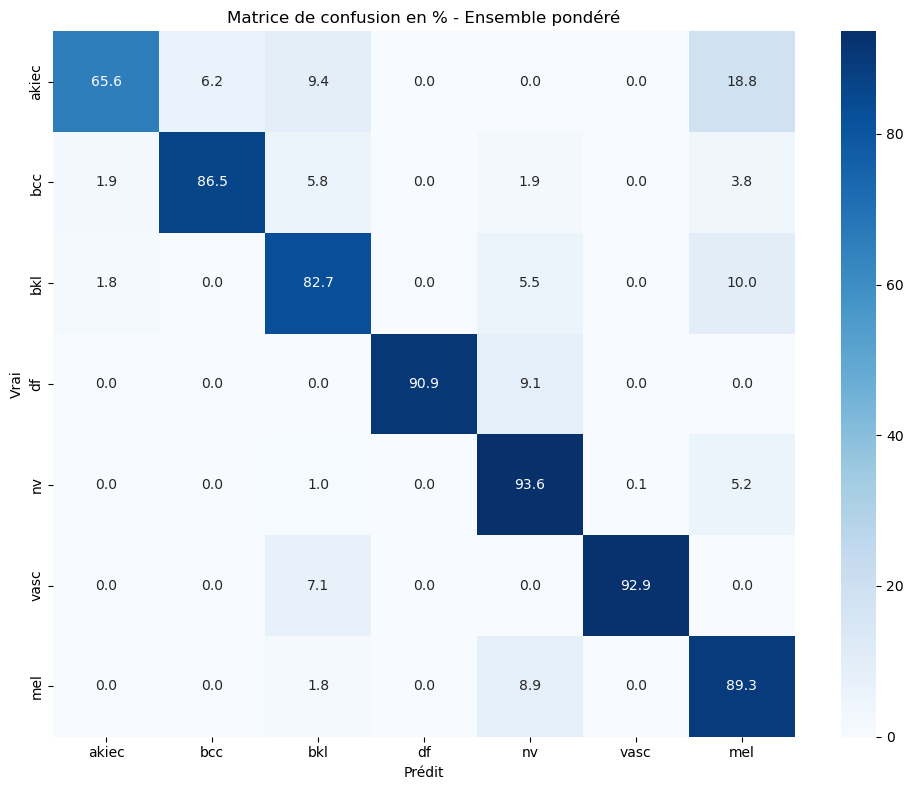

In [12]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as preprocess_efficientnet

# ---- Configuration ----
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
label_to_index = {name: i for i, name in enumerate(CLASS_NAMES)}

# ---- DataFrame df supposé dispo ----
df = df[df['dx'].isin(CLASS_NAMES)]
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))
df['label'] = df['dx'].map(label_to_index)

# Split train/val/test
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# ---- Chargement des modèles ----
model_xcept    = load_model("Protocole-S-V2-Xception-phaseSansTAG-valACC.keras", compile=False)
model_resnet50 = load_model("/Volumes/T9/Protocole-S-Best/Protocole-S-Resnet50.keras", compile=False)
model_effnet = load_model(
    "Protocole-S-V3-efficientNetSMALL-ph4ClassW8-valAUC.keras",
    compile=False,
    custom_objects={"preprocess_input": preprocess_efficientnet}
)

# ---- Préparation images ----
def load_image_paths(paths, target_size):
    return np.array([
        image.img_to_array(
            image.load_img(p, target_size=target_size, color_mode="rgb")
        ) for p in paths
    ])

# ---- Prédiction en batch avec priorisation EfficientNetV2Small sur mel ----
# weights=(0.45, 0.25, 0.30) -> Xception, ResNet50, EffNetV2Small
def predict_ensemble(image_paths, batch_size=32, weights=(0.30, 0.20, 0.50)):
    """
    weights = (w_xception, w_resnet50, w_effnet)
    """
    num_images = len(image_paths)
    all_predictions = []

    for i in tqdm(range(0, num_images, batch_size), desc="Prédiction par batchs"):
        batch_paths = image_paths[i:i + batch_size]

        # Chargement images adaptées
        bx = preprocess_xception(load_image_paths(batch_paths, (299, 299)))
        br = preprocess_resnet(load_image_paths(batch_paths, (224, 224)))
        be = preprocess_efficientnet(load_image_paths(batch_paths, (384, 384)))

        # Prédictions
        pred_x = model_xcept.predict(bx, verbose=0)
        pred_r = model_resnet50.predict(br, verbose=0)
        pred_e = model_effnet.predict(be, verbose=0)

        # Moyenne pondérée
        preds = (weights[0] * pred_x +
                 weights[1] * pred_r +
                 weights[2] * pred_e)

        # --- ASTUCE : privilégier EffNetV2Small pour 'mel' (classe index 6) ---
        mel_idx = label_to_index['mel']
        preds[:, mel_idx] = (0.5 * preds[:, mel_idx] + 0.5 * pred_e[:, mel_idx])

        all_predictions.extend(np.argmax(preds, axis=1))

    return np.array(all_predictions)

# ---- Évaluation ----
print("\nÉvaluation de l'ensemble pondéré (Xception + ResNet50 + EfficientNetV2Small)...")

y_true = test_df['label'].values
y_pred = predict_ensemble(test_df['path'].tolist())

print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                            target_names=CLASS_NAMES,
                            labels=np.arange(len(CLASS_NAMES))))

# ---- Matrice de confusion en % ----
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
conf_matrix_perc = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_perc, annot=True, fmt=".1f", cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion en % - Ensemble pondéré')
plt.tight_layout()
plt.show()
